In [1]:
import TDD_scaled as TDDS
import time

In [2]:
# soft hard 
states = TDDS.generate_states(TDDS.N + 1)
len(states)

14188744

In [3]:
# A fastest, more difference
# Changed V_end for all 
# Added infeasibility rule for w
# N = 10, SCALE = 0.2, different scaling, DRS_RANGE = 0.5, t_drs not scaled, second discretize_g, delta = g_step, g_AB1 = -g_step, g_AC1 = -2 * g_step
# no scaling of lambda_pen, g_step = 0.4, g_min/max = (-)3.5

start = time.time()

U, pi_A, pi_BC, xA_star, xBC_star = TDDS.solve_DP(objective="simple")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^BC (mixed strategy):\n{pi_BC}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[0.5 0.9 0.5 0.9]
 [0.1 0.5 0.5 0.5]]
π^A (mixed strategy): 
[-0.  1.]
π^BC (mixed strategy):
[0. 0. 0. 1.]
Total runtime of the program is 23719.39671087265 seconds


In [4]:
TDDS.d0

{'A': 19.400000000000002, 'B': 19.560000000000002, 'C': 19.480000000000004}

In [4]:
# Simulation
stats = TDDS.run_simulations(U, pi_A, pi_BC, xA_star, xBC_star, n_sim=10000, objective="simple")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.0000
P(BC wins): 1.0000
Mean gap g_AB: 0.5000
Mean gap g_AC: -3.1000
Std gap g_AB: 0.0000
Std gap g_AC: 0.0000
Mean gap g_AB | A wins: 0.0000
Mean gap g_AC | A wins: 0.0000
Mean gap g_AB | BC wins: 0.5000
Mean gap g_AC | BC wins: -3.1000
Std gap g_AB | A wins: 0.0000
Std gap g_AC | A wins: 0.0000
Std gap g_AB | BC wins: 0.0000
Std gap g_AC | BC wins: 0.0000


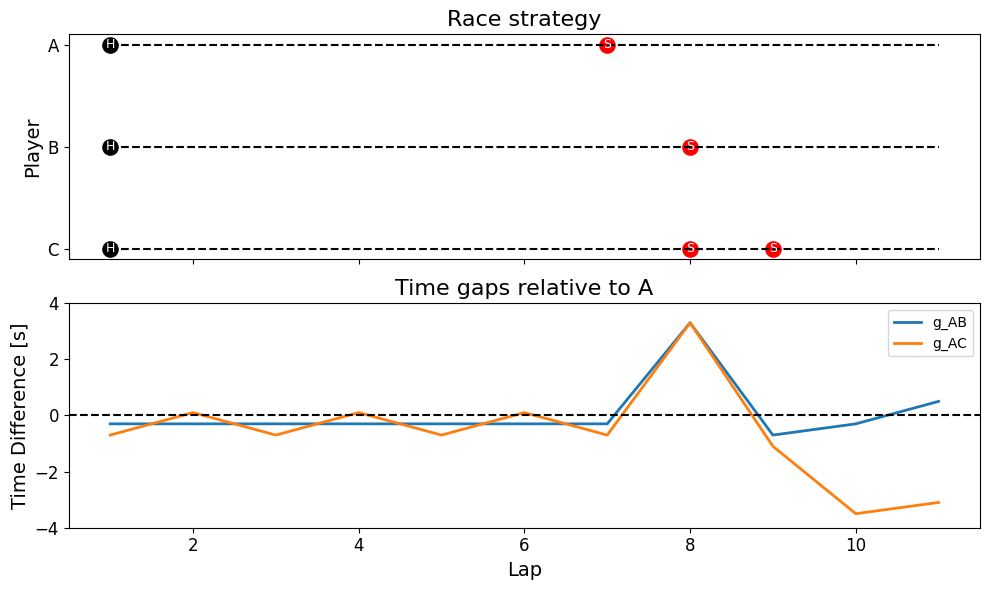

In [5]:
_, _, h, g, p = TDDS.simulate_race(pi_A, pi_BC, xA_star, xBC_star)
TDDS.plot_sample_path(h, g, p)

In [ ]:
# 10:17

In [1]:
import smG_scaled as smGS
import time

In [7]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
states = smGS.generate_states(smGS.N + 1)
len(states)

6176304

In [8]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
start = time.time()

U, pi_A, pi_B, xA_star, xB_star = smGS.solve_SDP(objective="gap")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^B (mixed strategy):\n{pi_B}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[-0.62361229 -0.15979968]
 [-0.57358546 -0.66055776]]
π^A (mixed strategy): 
[0.15790611 0.84209389]
π^B (mixed strategy):
[0.90917176 0.09082824]
Total runtime of the program is 21923.88584780693 seconds


In [9]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="gap")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7534
P(B wins): 0.2466
P(tie): 0.0000
Mean gap: -0.5977
Std gap: 0.7856
Mean gap | A wins: -0.9371
Mean gap | B wins: 0.4391
Std gap | A wins: 0.5489
Std gap | B wins: 0.3940


Winner: A
Gap: -2.1999999999999975
Winner: A
Gap: -0.9999999999999964


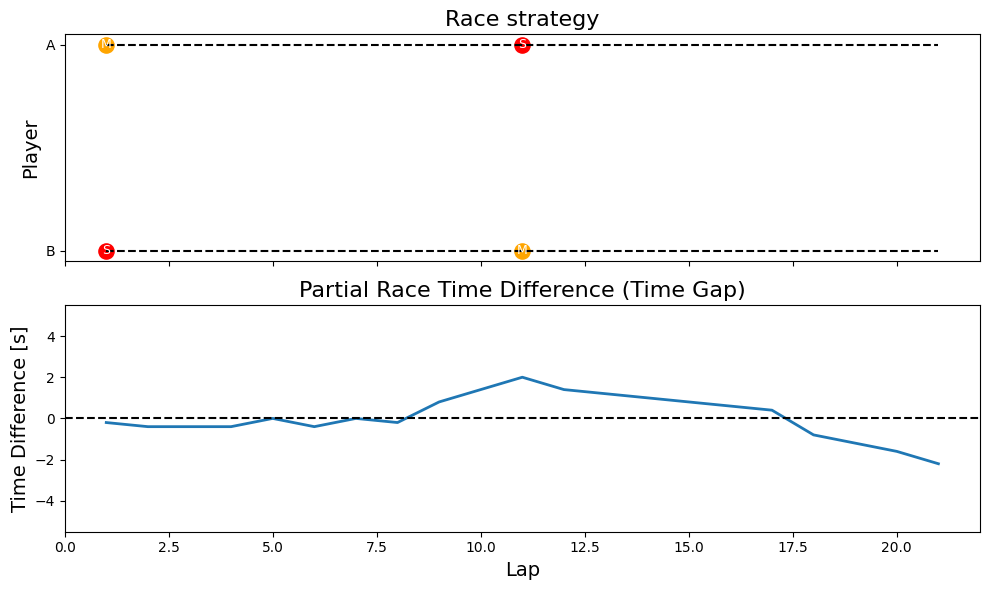

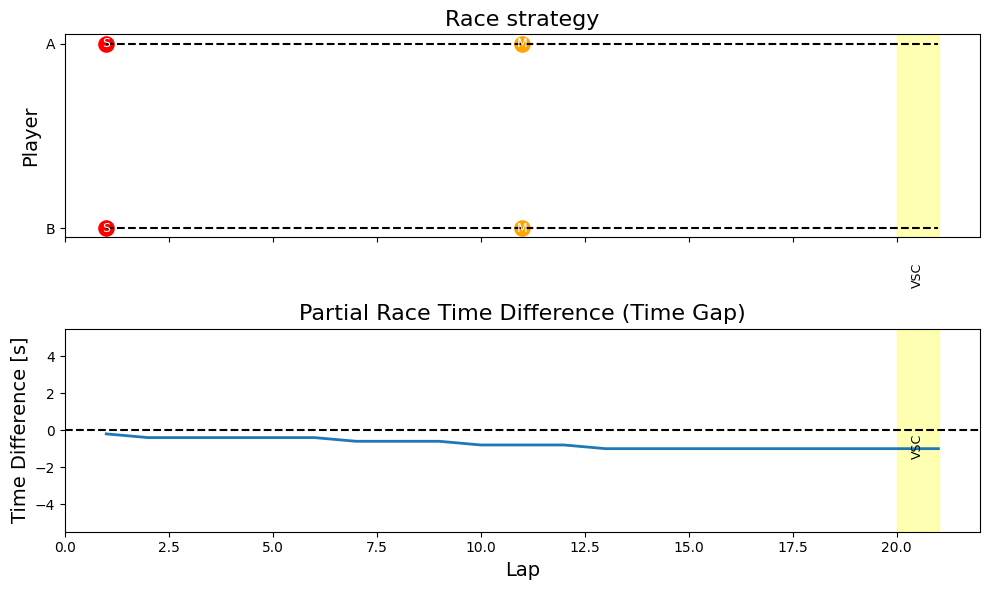

In [10]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [ ]:
# 17:15

In [ ]:
# SAVE THE POLICIES

Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 0.20000000000000462


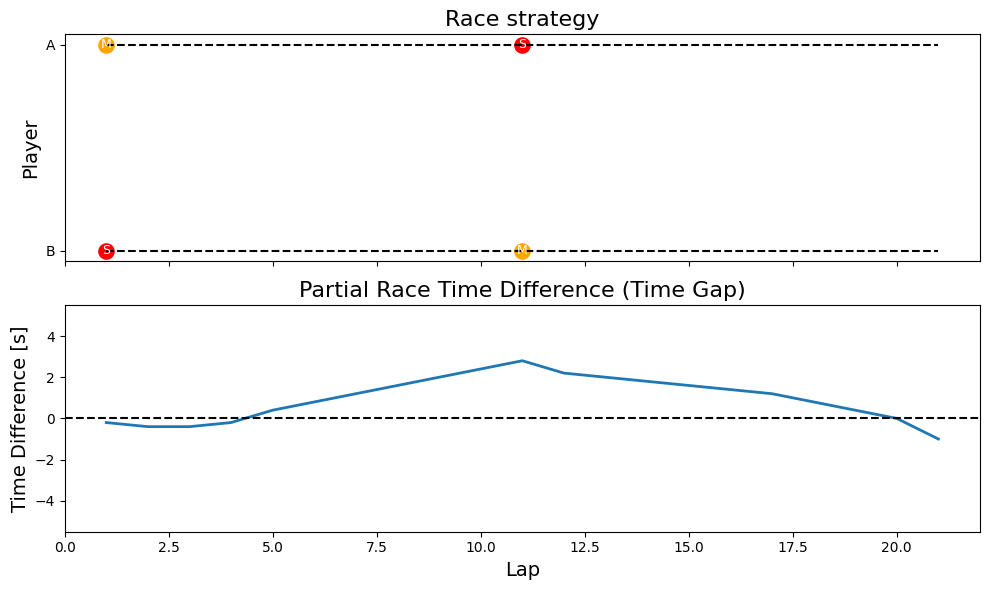

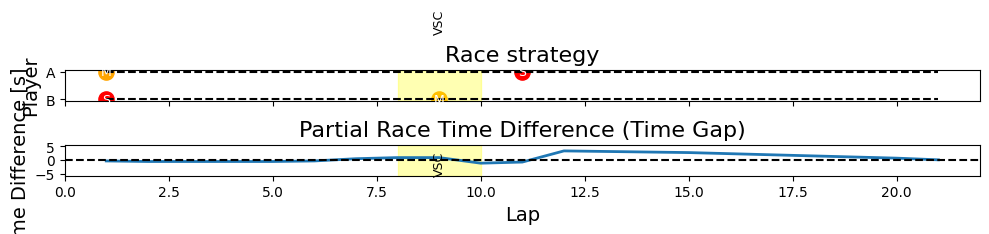

In [11]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -2.3999999999999977
Winner: B
Gap: 0.600000000000005


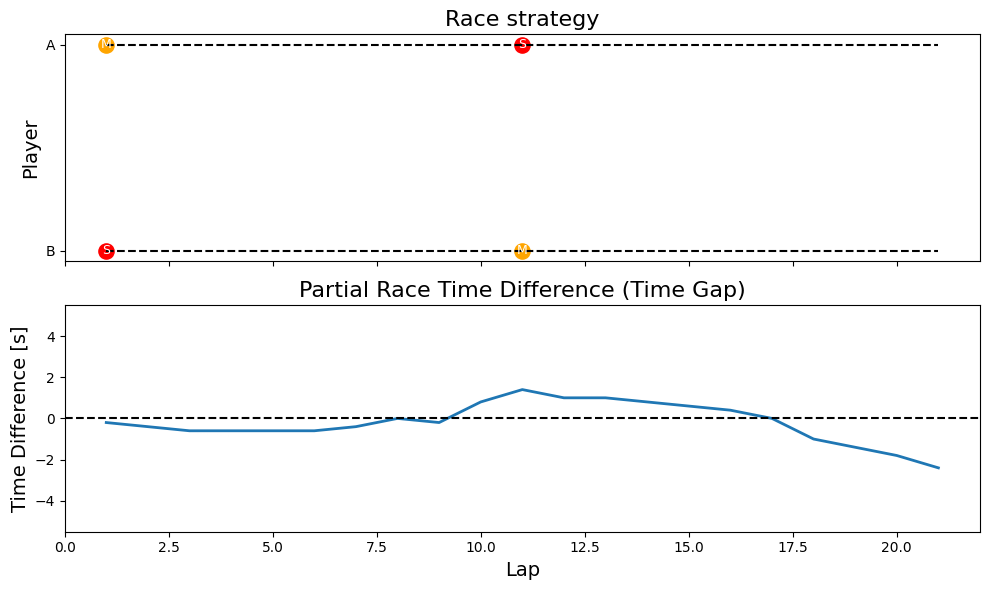

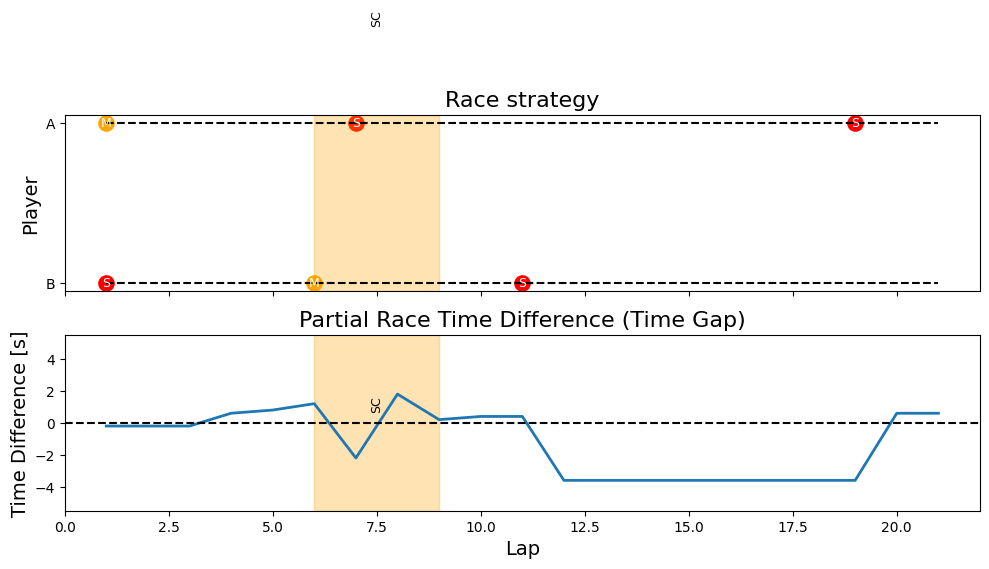

In [12]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.19999999999999574
Winner: B
Gap: 0.600000000000005


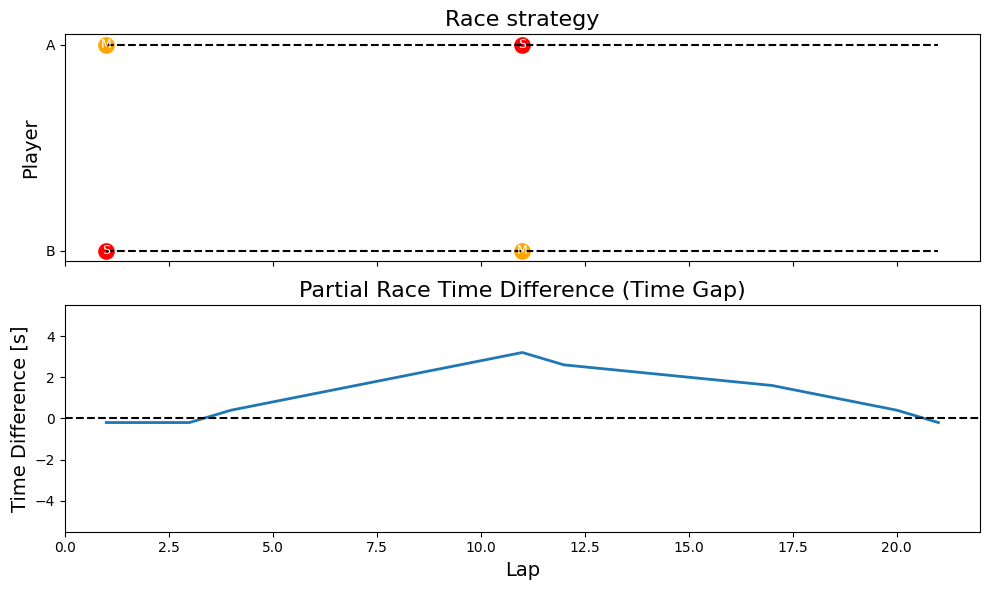

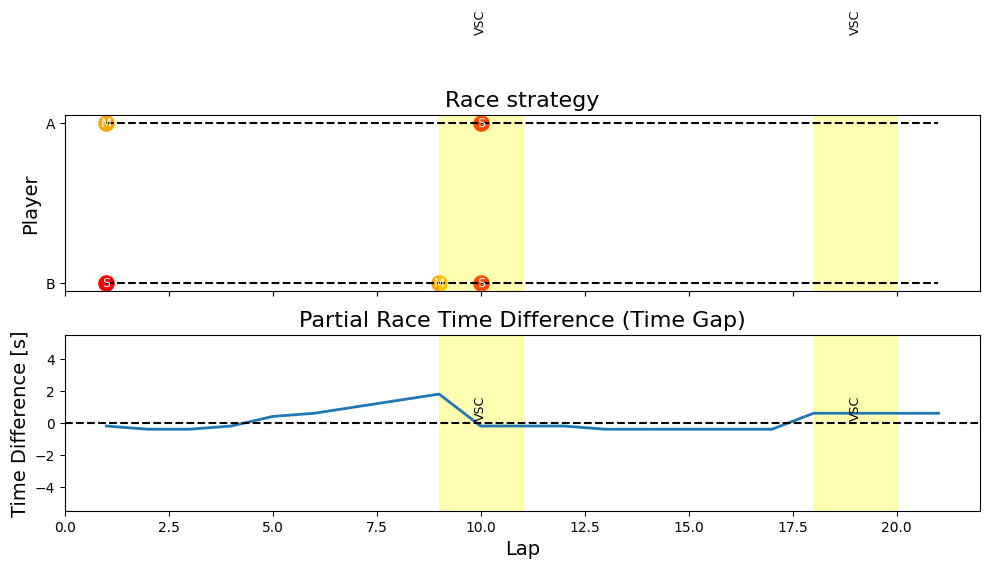

In [14]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.7999999999999963
Winner: A
Gap: -0.7999999999999963


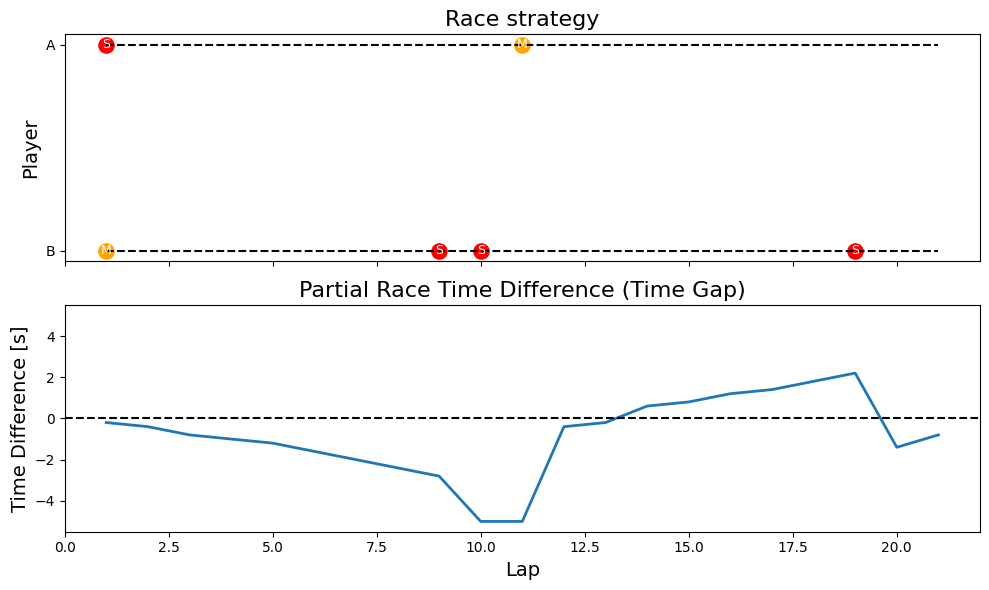

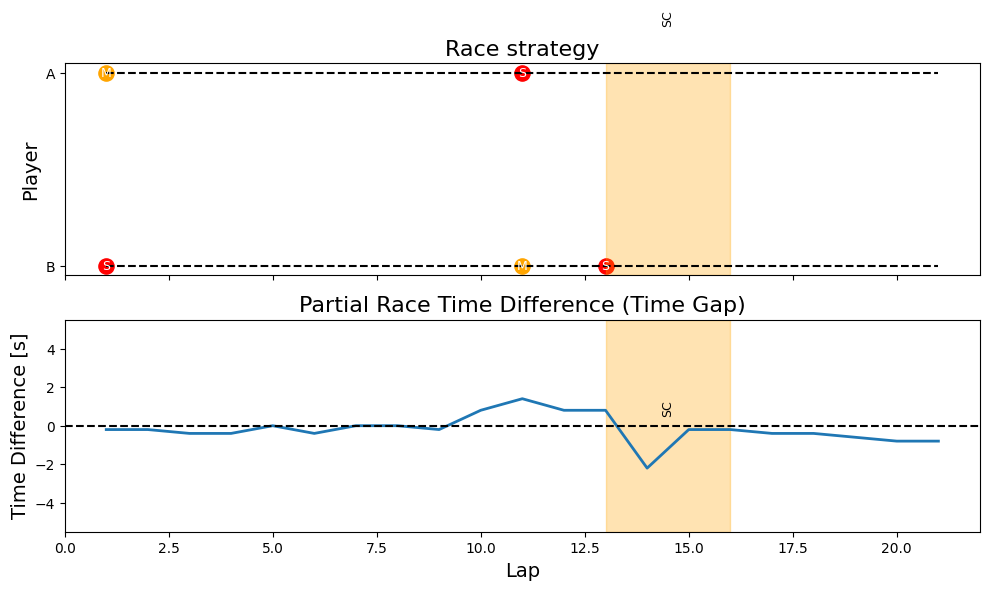

In [17]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [2]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
states = smGS.generate_states(smGS.N + 1)
len(states)

6176304

In [3]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
start = time.time()

U, pi_A, pi_B, xA_star, xB_star = smGS.solve_SDP(objective="win")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^B (mixed strategy):\n{pi_B}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[-0.52766338 -0.31044165]
 [-0.42759929 -0.53636827]]
π^A (mixed strategy): 
[0.33365669 0.66634331]
π^B (mixed strategy):
[0.69304619 0.30695381]
Total runtime of the program is 21094.439959049225 seconds


In [4]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="win")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7355
P(B wins): 0.2645
P(tie): 0.0000
Mean gap: -1.0053
Std gap: 1.8991
Mean gap | A wins: -1.7408
Mean gap | B wins: 1.0398
Std gap | A wins: 1.5268
Std gap | B wins: 1.2113


Winner: A
Gap: -1.9999999999999973
Winner: A
Gap: -0.5999999999999961


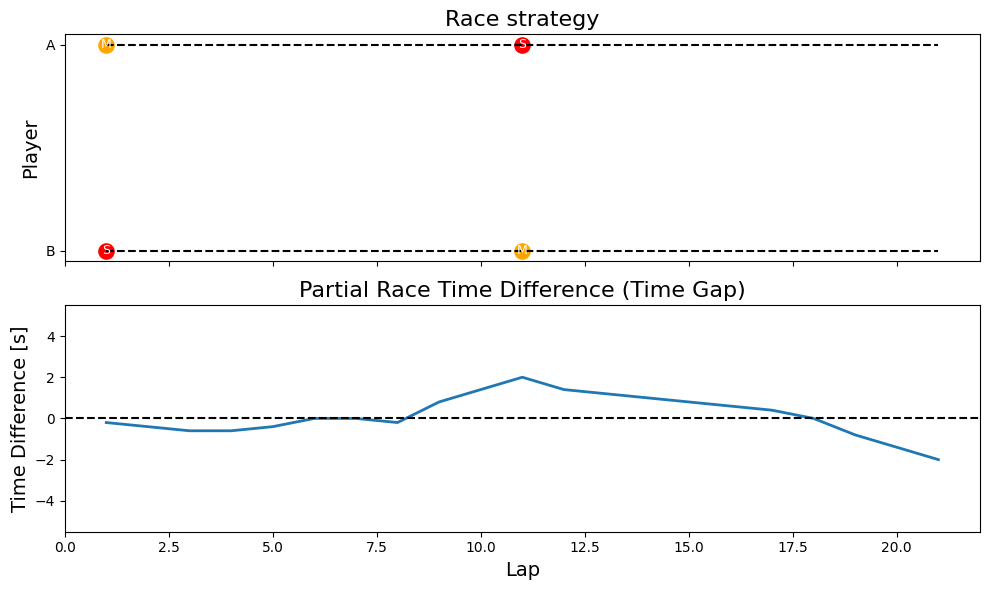

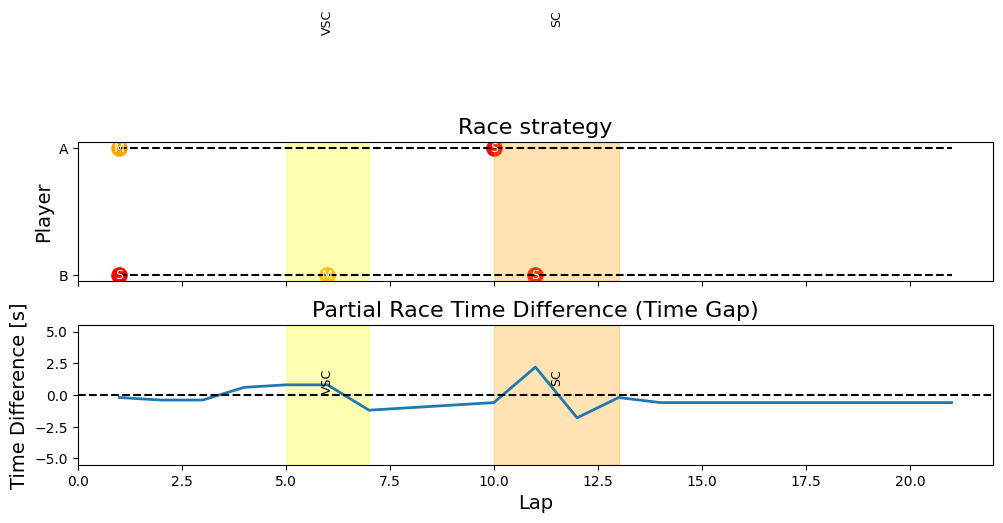

In [5]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 0.8000000000000052


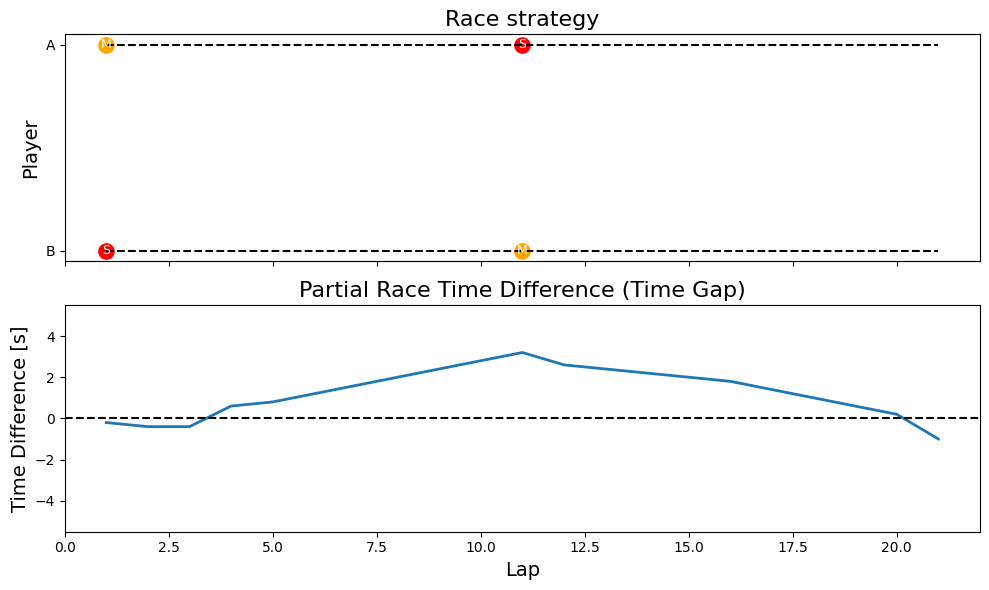

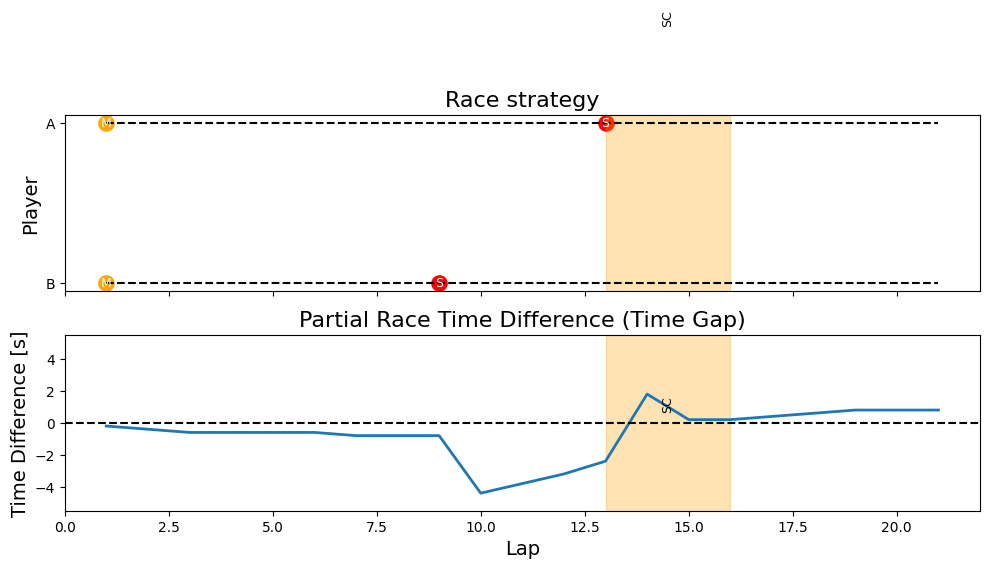

In [6]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -3.999999999999999
Winner: B
Gap: 0.20000000000000462


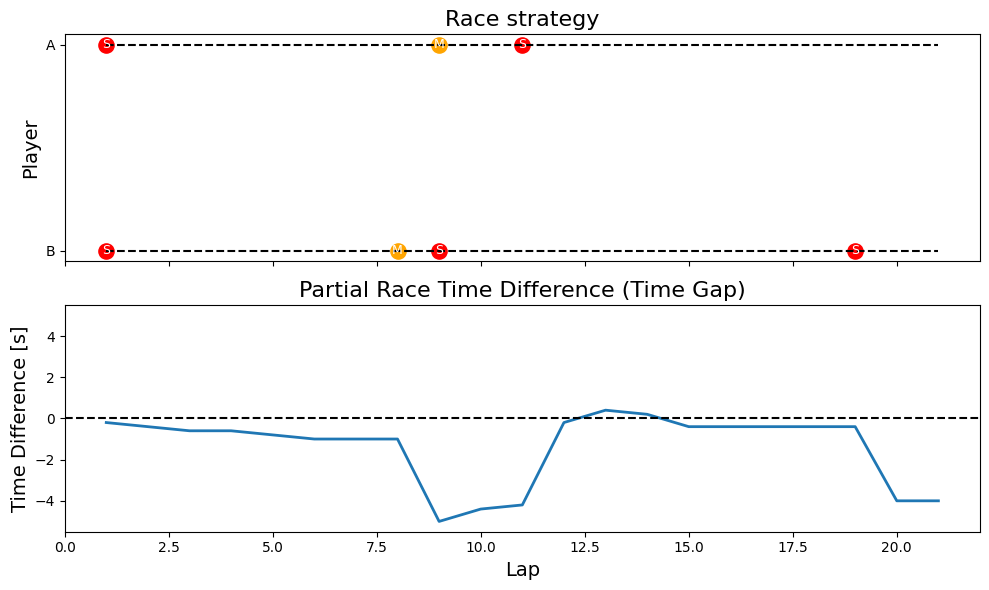

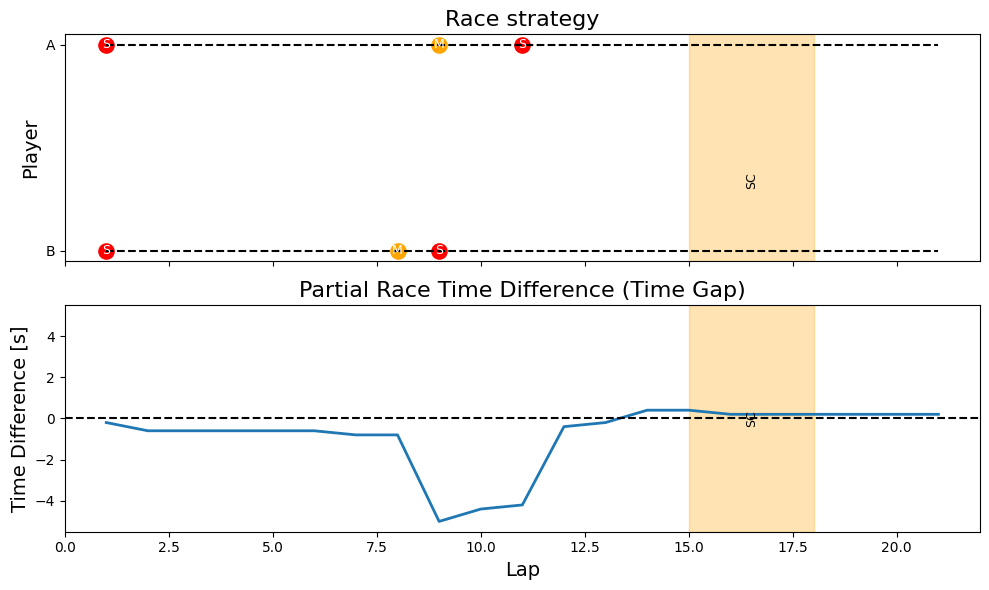

In [7]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [8]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="win")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7301
P(B wins): 0.2699
P(tie): 0.0000
Mean gap: -1.0356
Std gap: 1.9313
Mean gap | A wins: -1.7947
Mean gap | B wins: 1.0179
Std gap | A wins: 1.5575
Std gap | B wins: 1.2175


Winner: A
Gap: -0.19999999999999574
Winner: A
Gap: -5.0


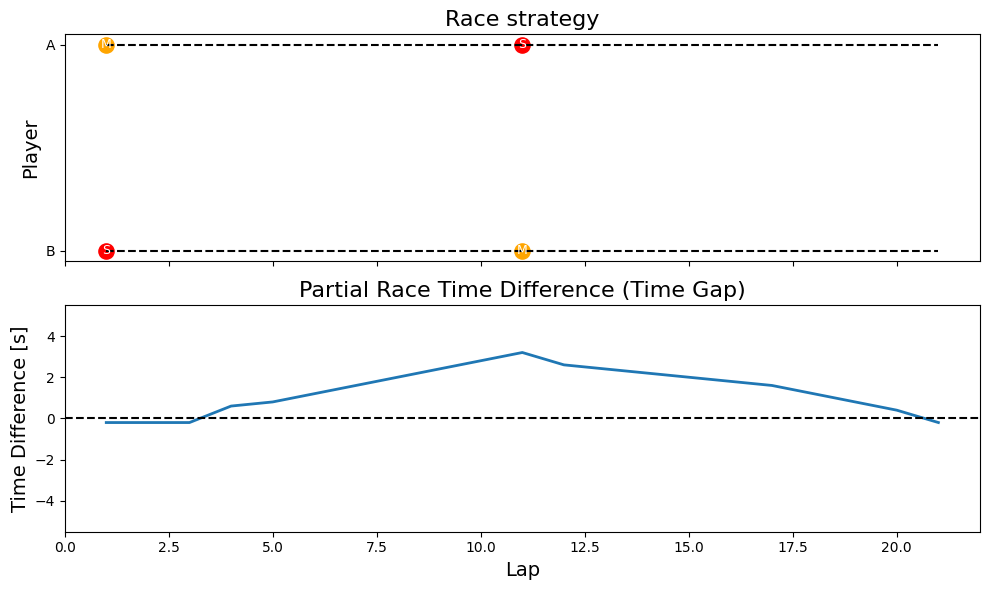

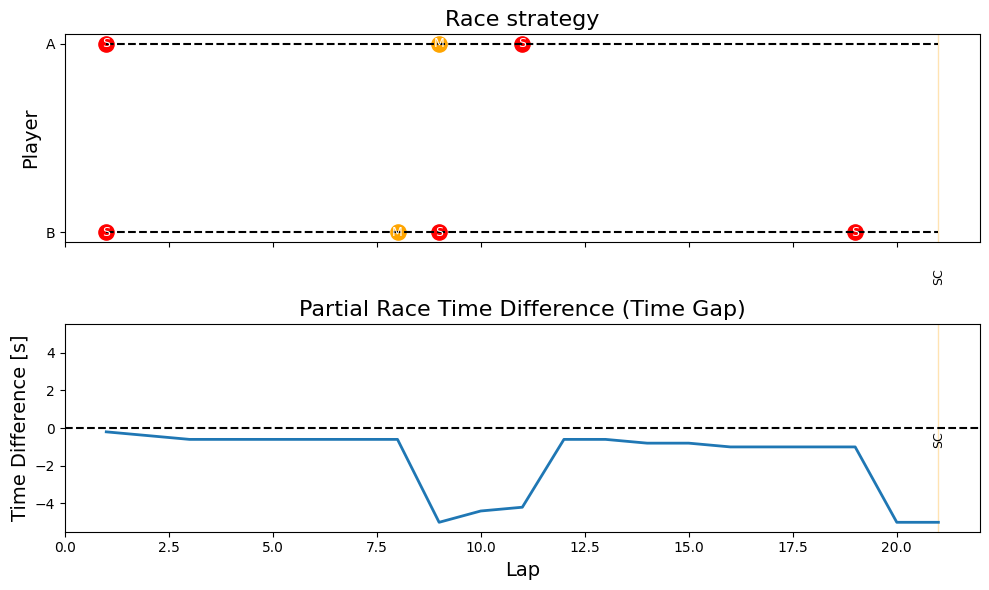

In [9]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.19999999999999574
Winner: B
Gap: 4.800000000000009


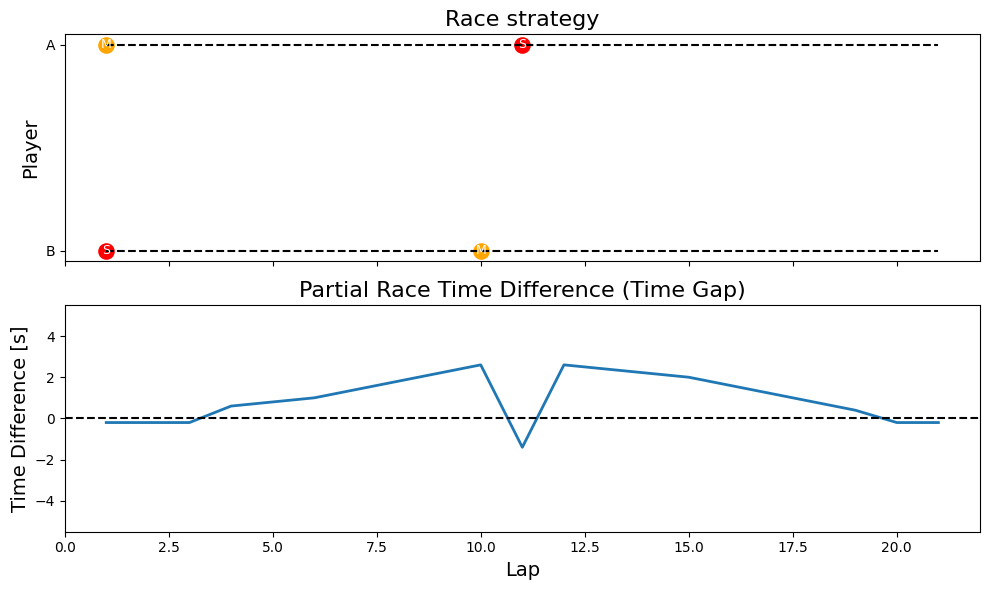

/Users/elevels/Documents/UM/Bachelor/Year 3/Thesis/Code/Thesis-F1-Pit-Stop-Optimization/smG_scaled.py:745: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


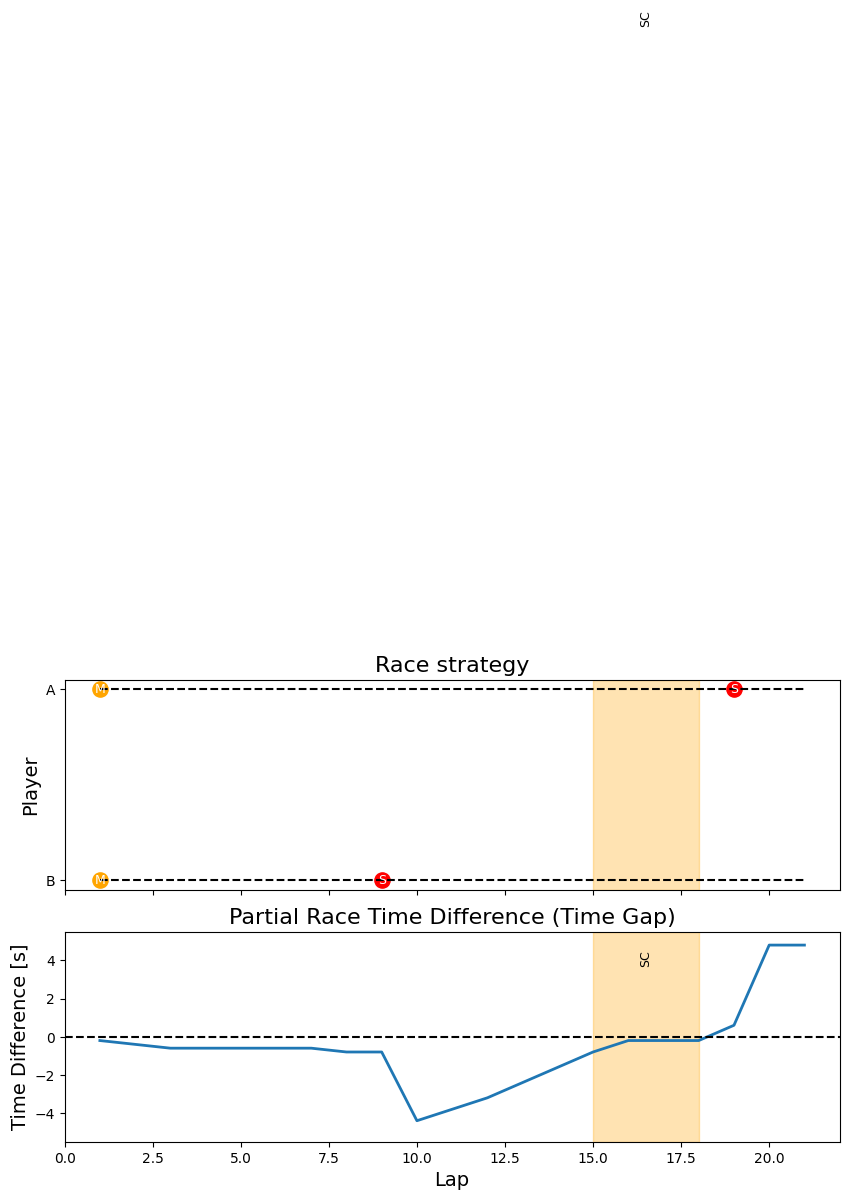

In [10]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.7999999999999963
Winner: A
Gap: -2.3999999999999977


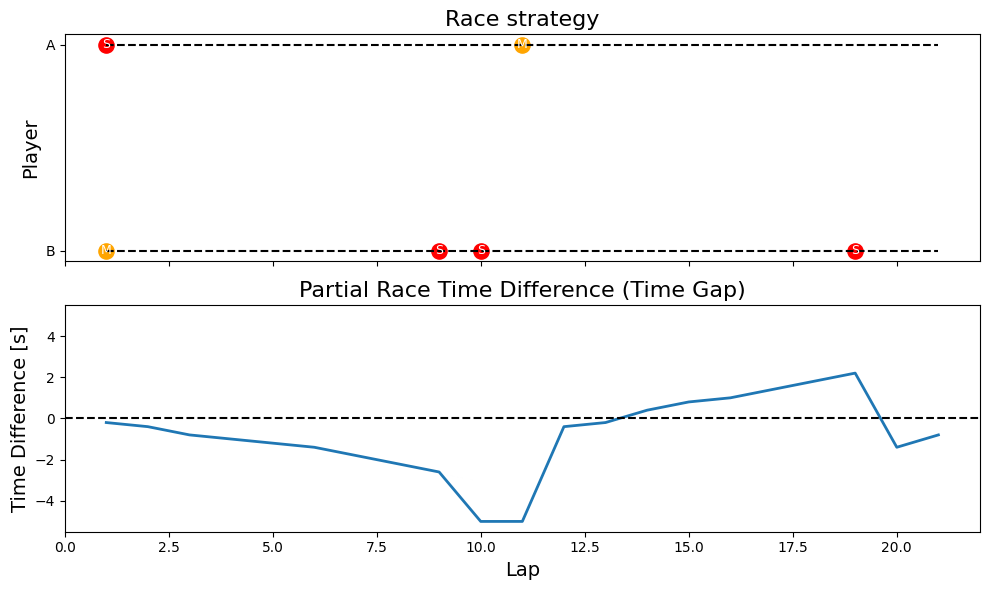

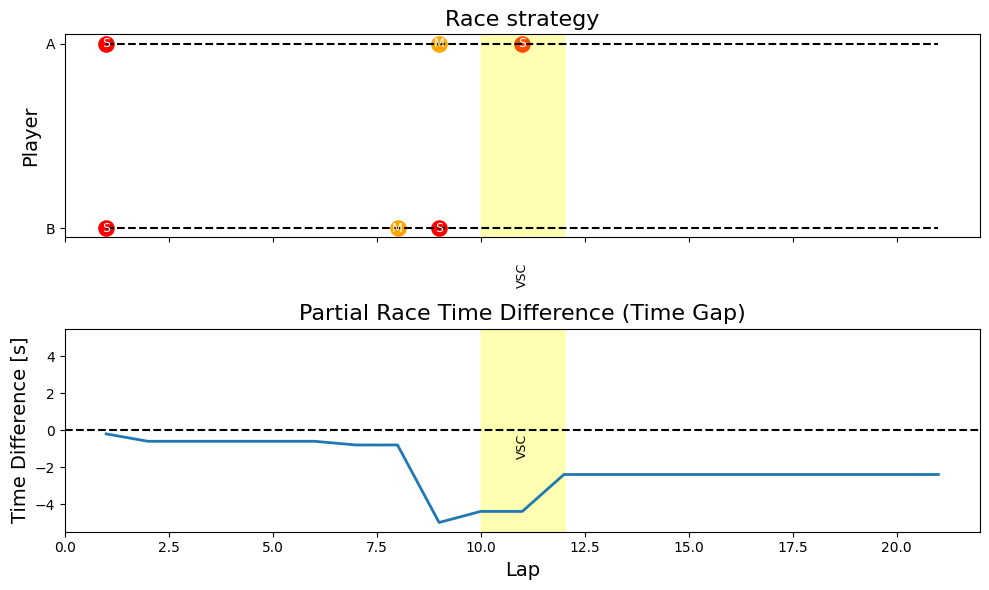

In [11]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -1.599999999999997
Winner: A
Gap: -1.7999999999999972


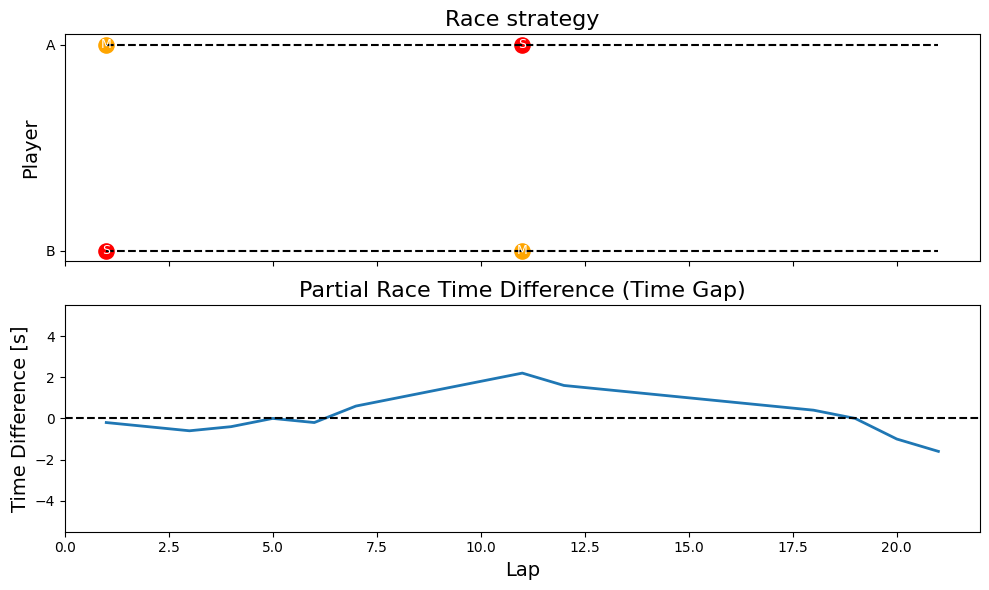

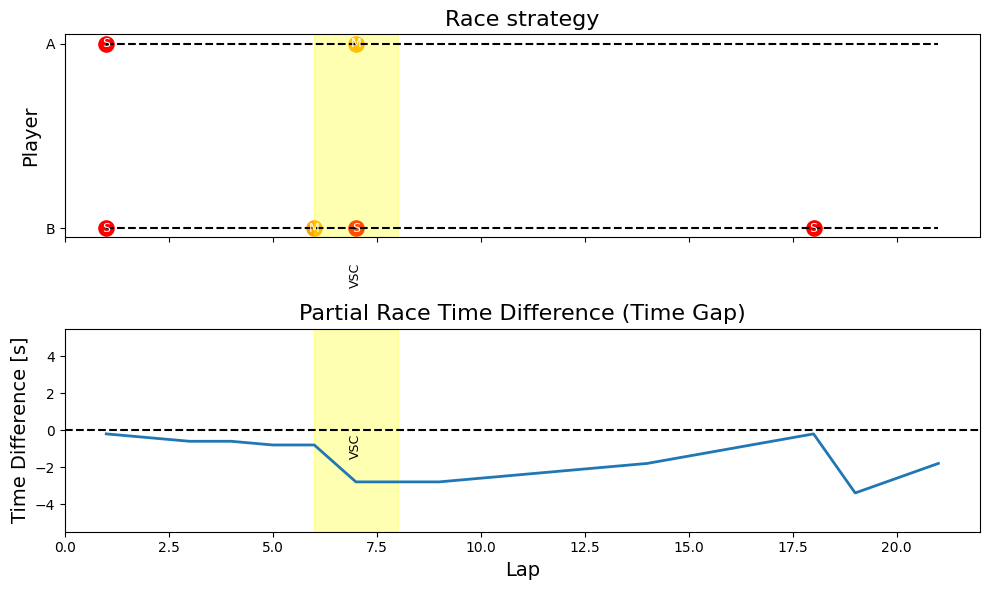

In [12]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [1]:
import smG_scaled as smGS
import time

In [2]:
smGS.T

[1, 3]

In [3]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
states = smGS.generate_states(smGS.N + 1)
len(states)

7057584

In [4]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
start = time.time()

U, pi_A, pi_B, xA_star, xB_star = smGS.solve_SDP(objective="gap")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^B (mixed strategy):\n{pi_B}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[-0.63399045 -0.21883517]
 [-0.06013788 -0.6628838 ]]
π^A (mixed strategy): 
[0.59214579 0.40785421]
π^B (mixed strategy):
[0.43623942 0.56376058]
Total runtime of the program is 22739.18686580658 seconds


In [5]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="gap")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7144
P(B wins): 0.2856
P(tie): 0.0000
Mean gap: -0.3843
Std gap: 0.6690
Mean gap | A wins: -0.7462
Mean gap | B wins: 0.5210
Std gap | A wins: 0.3398
Std gap | B wins: 0.3621


Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 1.2000000000000055


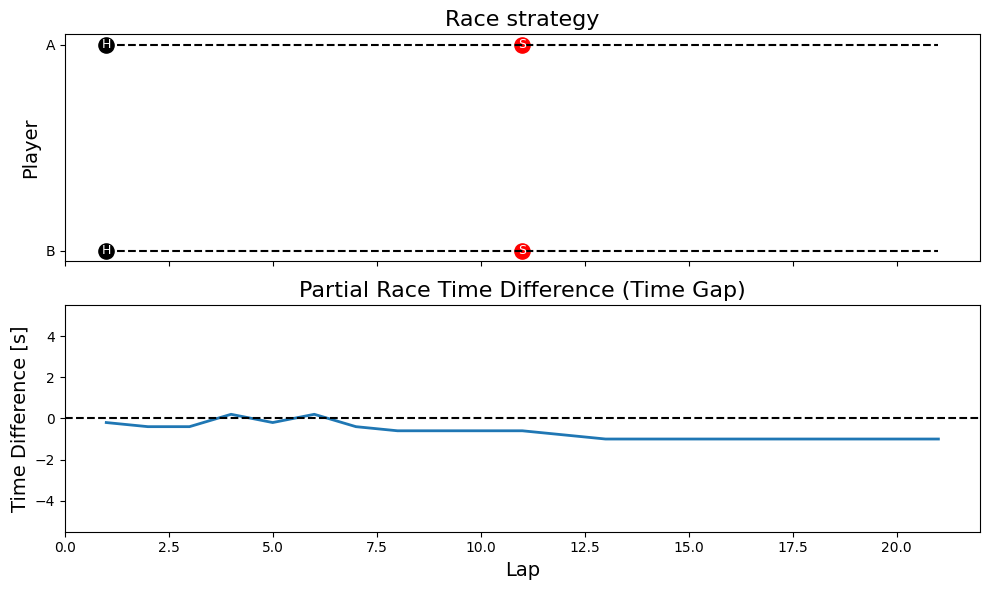

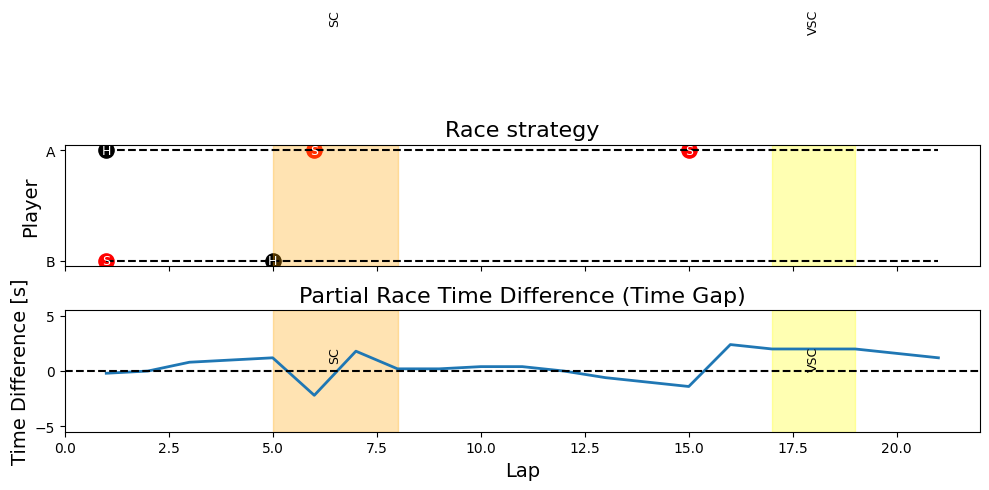

In [6]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.7999999999999963
Winner: B
Gap: 0.600000000000005


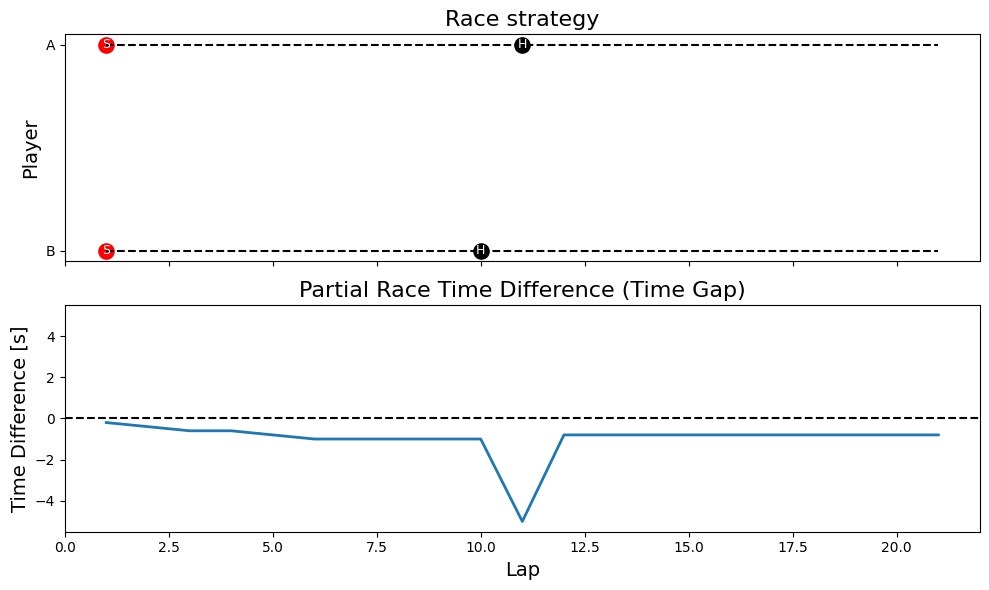

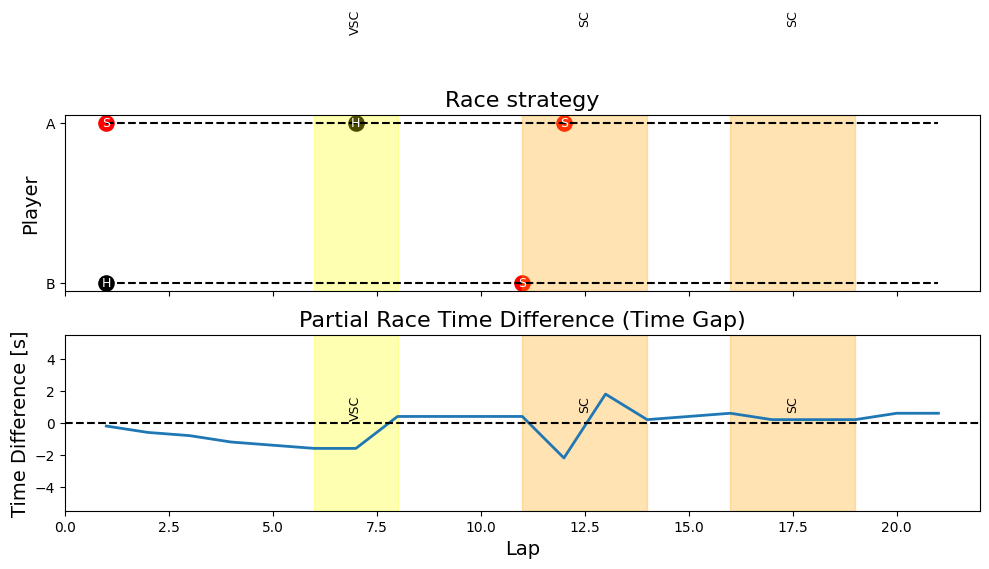

In [8]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: B
Gap: 0.4000000000000048
Winner: B
Gap: 4.440892098500626e-15


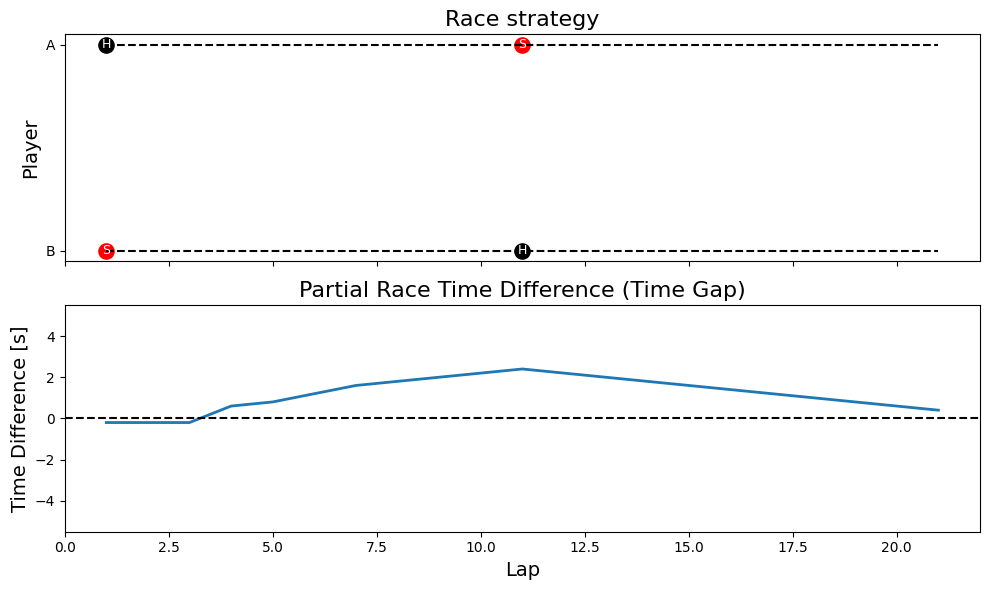

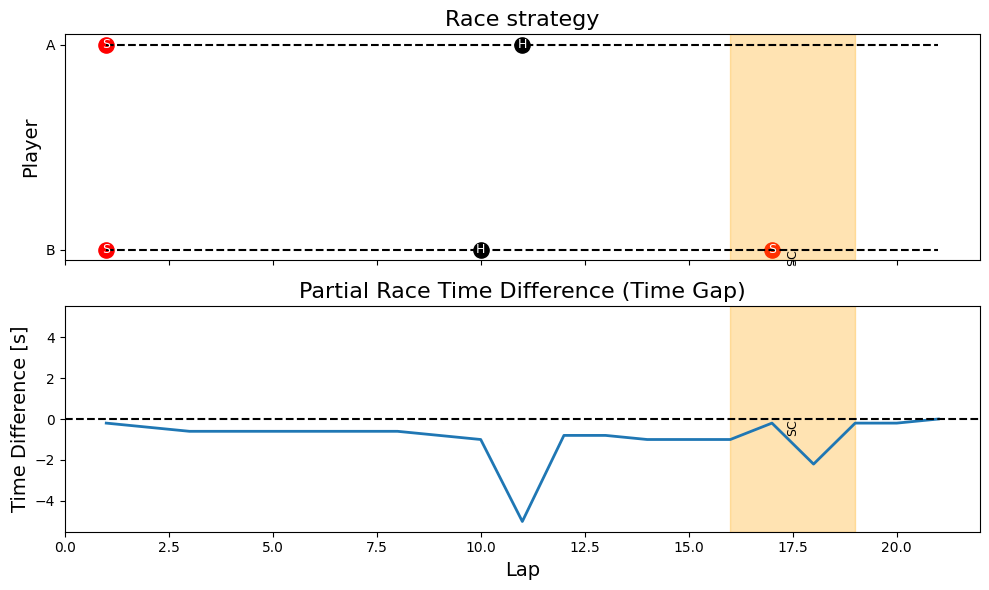

In [9]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 0.8000000000000052


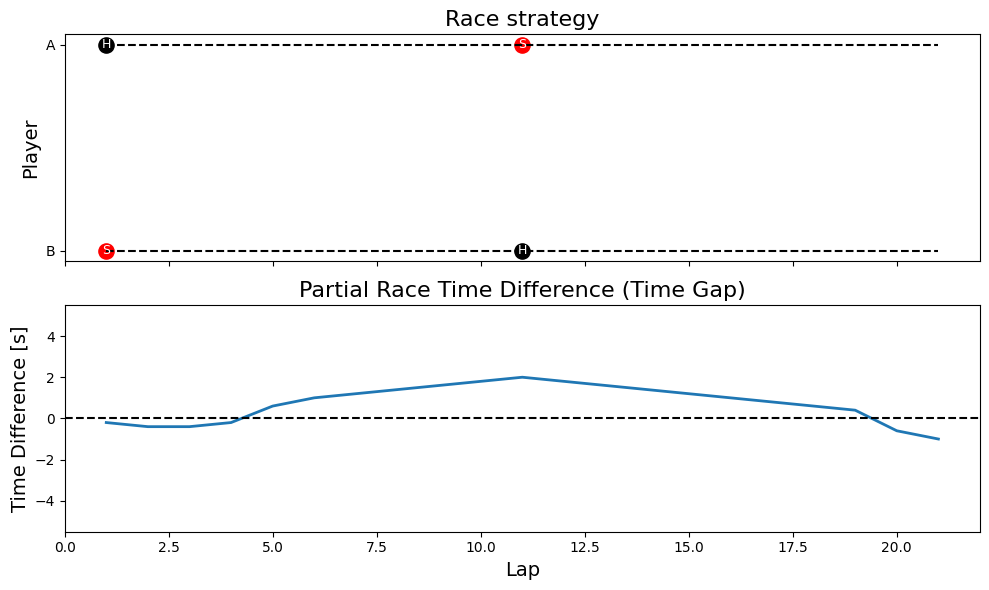

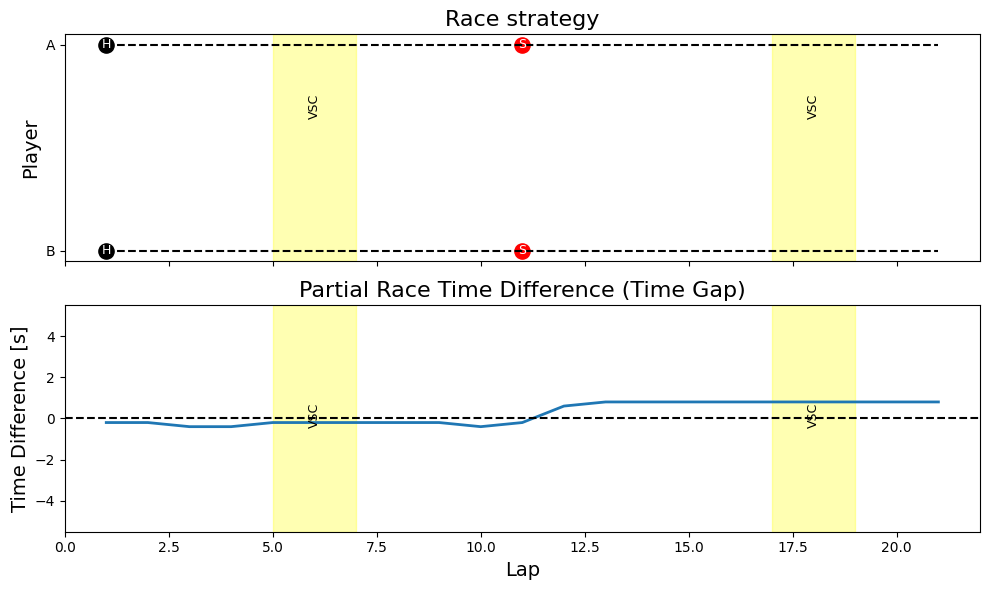

In [13]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.3999999999999959
Winner: B
Gap: 0.20000000000000462


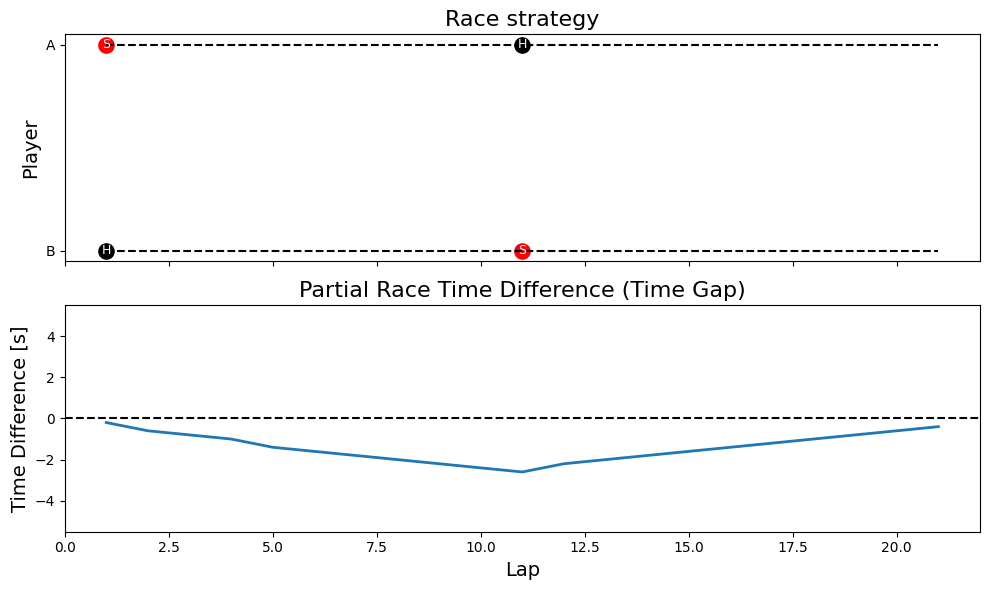

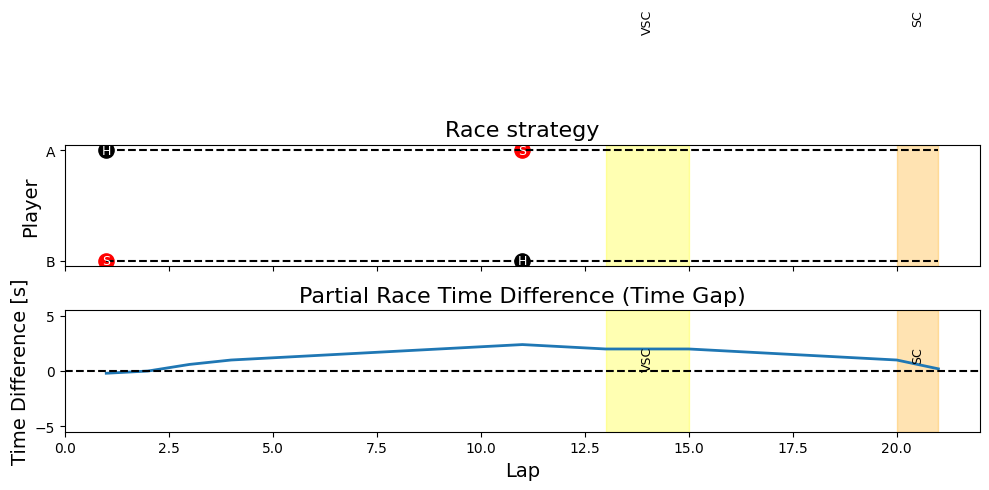

In [15]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: B
Gap: 0.8000000000000052
Winner: B
Gap: 0.8000000000000052


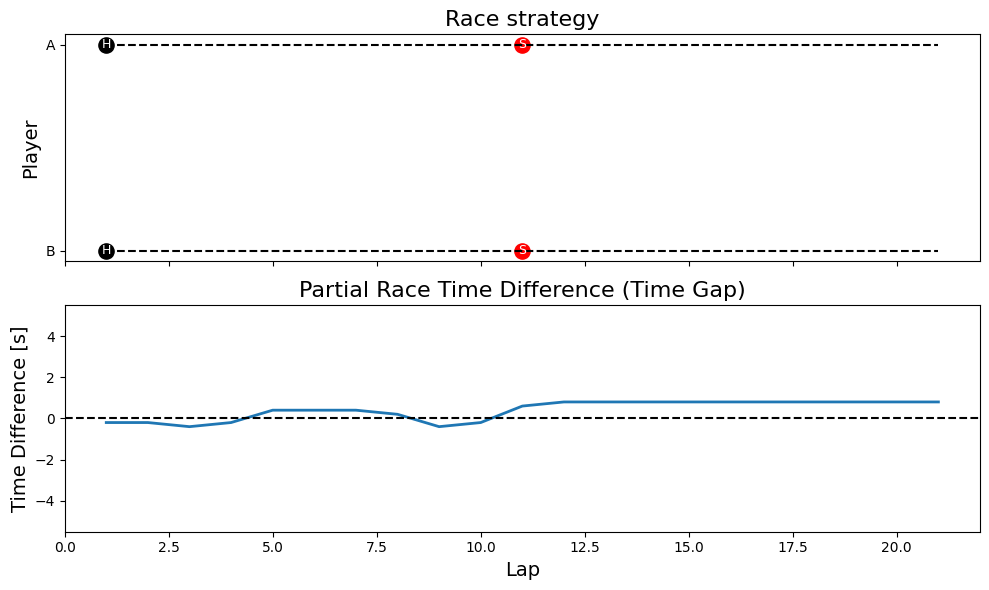

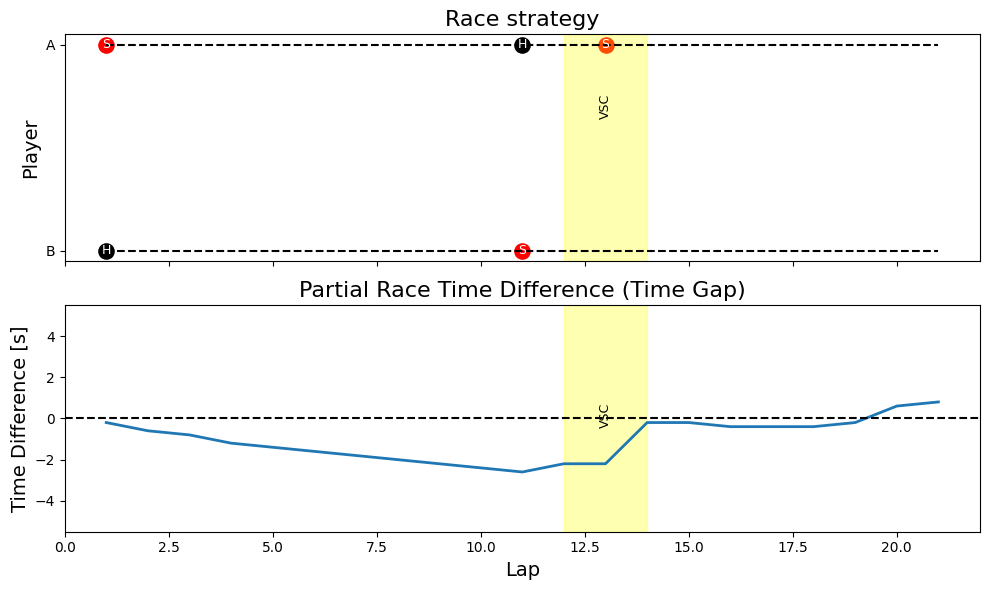

In [16]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: B
Gap: 0.4000000000000048
Winner: A
Gap: -0.9999999999999964


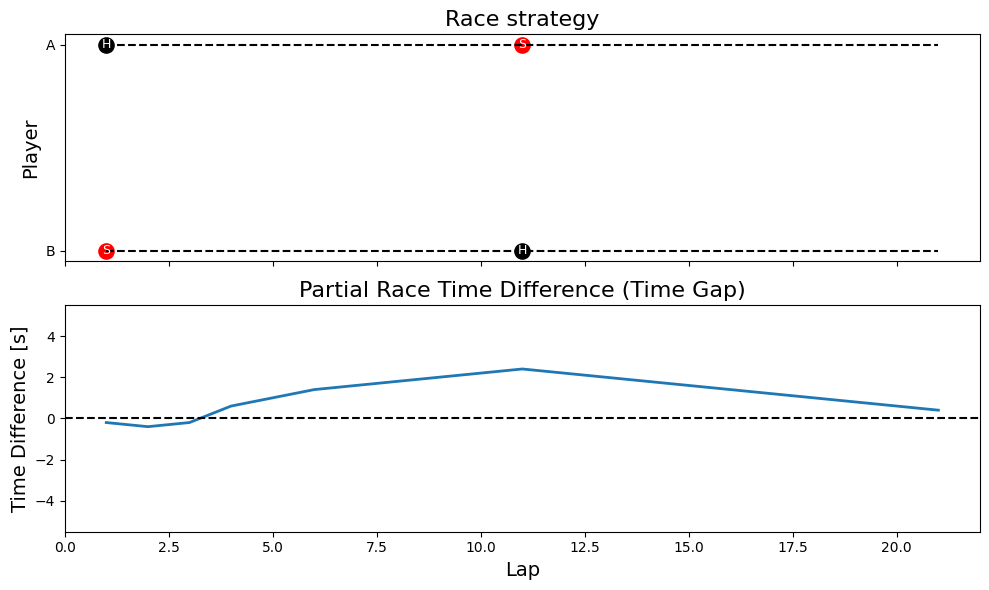

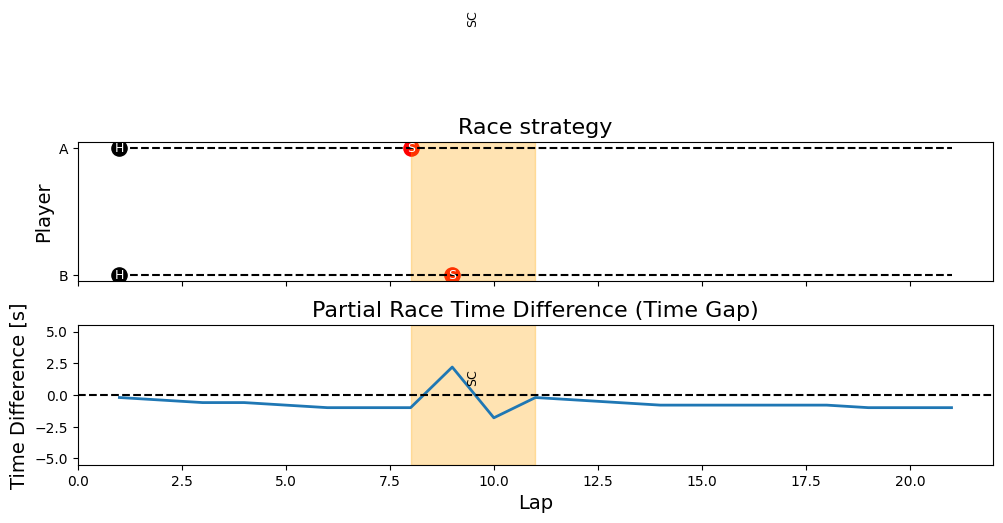

In [20]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 0.600000000000005


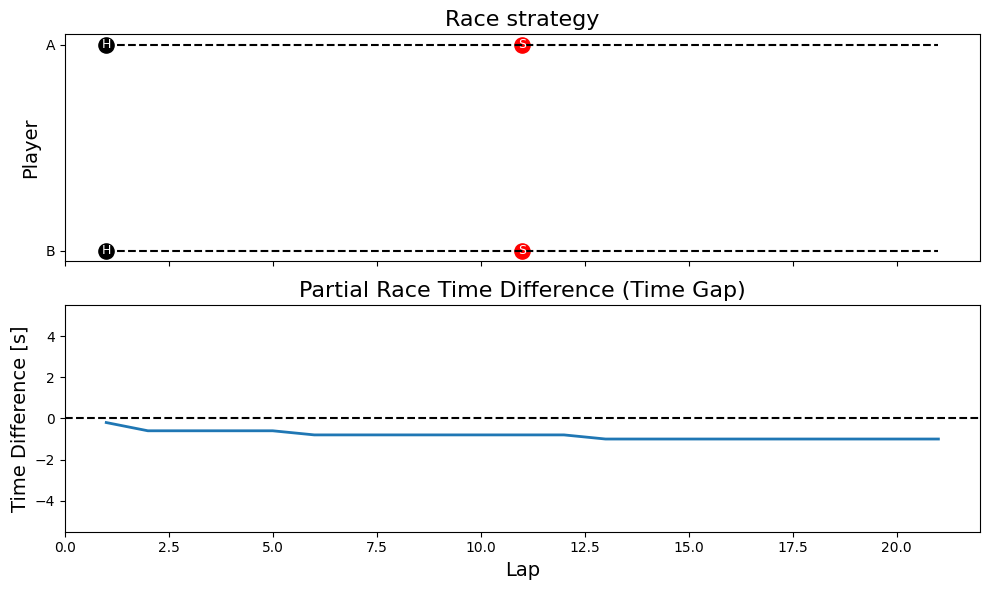

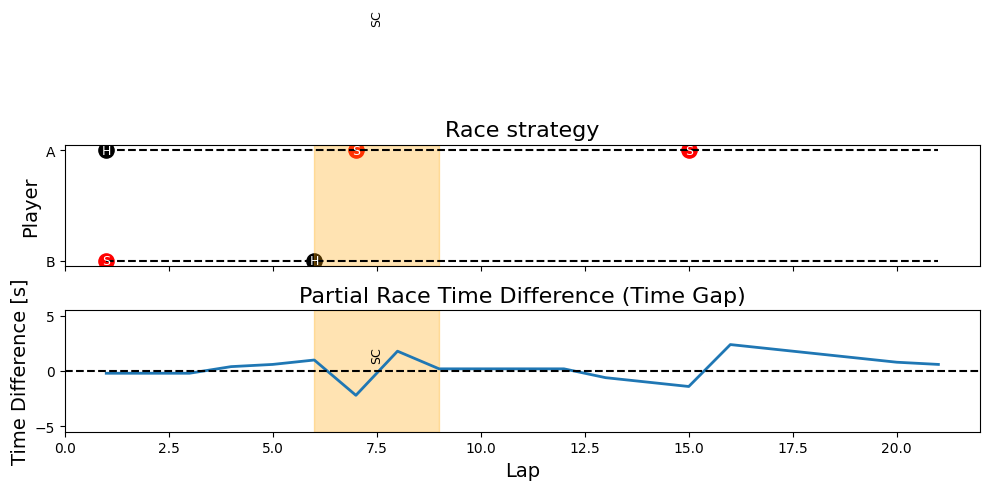

In [24]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [ ]:
# MAybe save the final gaps from the 10.000 races for statistical tests?

In [27]:
import pandas as pd
import numpy as np

def run_simulations_save_csv(
    experiment_name,
    objective,
    tire_set,
    U,
    pi_A,
    pi_B,
    xA_star,
    xB_star,
    n_sim=10000
):

    rows = []

    for sim_id in range(n_sim):

        g_final, winner, history, gap_history, yellow_history, pit_history = smGS.simulate_race(
            pi_A,
            pi_B,
            xA_star,
            xB_star,
            objective
        )

        # Initial tires
        start_tire_A = history[0][1]
        start_tire_B = history[0][2]

        # Number of pit stops
        n_pits_A = sum(p[0] for p in pit_history)
        n_pits_B = sum(p[1] for p in pit_history)

        # Yellow flags
        had_VSC = any(yV > 0 for (yV, yS) in yellow_history)
        had_SC = any(yS > 0 for (yV, yS) in yellow_history)

        rows.append({

            "experiment": experiment_name,
            "objective": objective,
            "tire_set": str(tire_set),

            "simulation_id": sim_id,

            "final_gap": g_final,
            "winner": winner,

            "A_wins": int(winner == "A"),
            "B_wins": int(winner == "B"),
            "tie": int(winner == "tie"),

            "start_tire_A": start_tire_A,
            "start_tire_B": start_tire_B,

            "n_pits_A": n_pits_A,
            "n_pits_B": n_pits_B,

            "had_VSC": int(had_VSC),
            "had_SC": int(had_SC),

            "mean_gap_race": np.mean(gap_history),
            "std_gap_race": np.std(gap_history)
        })

    df = pd.DataFrame(rows)

    filename = f"{experiment_name}.csv"

    df.to_csv(filename, index=False)

    print(f"Saved results to: {filename}")

    return df

In [28]:
df_exp_SH_gap = run_simulations_save_csv(experiment_name="EXP_SH_gap", objective="gap", tire_set=smGS.T, U=U, pi_A=pi_A, pi_B=pi_B, xA_star=xA_star, xB_star=xB_star, n_sim=10000)

Saved results to: EXP_SH_gap.csv


In [29]:
df_exp_SH_gap

,experiment,objective,tire_set,simulation_id,final_gap,winner,A_wins,B_wins,tie,start_tire_A,start_tire_B,n_pits_A,n_pits_B,had_VSC,had_SC,mean_gap_race,std_gap_race
0,EXP_SH_gap,gap,"[1, 3]",0,-1.400000e+00,A,1,0,0,3,1,1,2,1,0,-0.857143,0.656521
1,EXP_SH_gap,gap,"[1, 3]",1,-1.000000e+00,A,1,0,0,3,3,1,1,0,0,-0.847619,0.238286
2,EXP_SH_gap,gap,"[1, 3]",2,4.440892e-15,B,0,1,0,1,3,1,1,1,0,-0.828571,0.858095
3,EXP_SH_gap,gap,"[1, 3]",3,6.000000e-01,B,0,1,0,3,1,1,1,1,0,1.171429,0.693605
4,EXP_SH_gap,gap,"[1, 3]",4,-8.000000e-01,A,1,0,0,1,3,1,1,1,0,-1.571429,0.608779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EXP_SH_gap,gap,"[1, 3]",9995,-1.000000e+00,A,1,0,0,1,1,1,1,1,0,-1.038095,0.912598
9996,EXP_SH_gap,gap,"[1, 3]",9996,6.000000e-01,B,0,1,0,3,1,1,1,0,0,1.466667,0.751718
9997,EXP_SH_gap,gap,"[1, 3]",9997,-1.400000e+00,A,1,0,0,1,3,1,2,0,1,-0.504762,1.230747
9998,EXP_SH_gap,gap,"[1, 3]",9998,-2.000000e-01,A,1,0,0,1,3,1,1,0,0,-1.247619,0.638166


In [1]:
import smG_scaled as smGS
import time

In [2]:
smGS.T

[1, 3]

In [3]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
states = smGS.generate_states(smGS.N + 1)
len(states)

7057584

In [4]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
start = time.time()

U, pi_A, pi_B, xA_star, xB_star = smGS.solve_SDP(objective="win")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^B (mixed strategy):\n{pi_B}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[-0.56761494 -0.35824414]
 [ 0.17454244 -0.61386822]]
π^A (mixed strategy): 
[0.79016367 0.20983633]
π^B (mixed strategy):
[0.25619245 0.74380755]
Total runtime of the program is 22296.304530858994 seconds


In [5]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="win")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7057
P(B wins): 0.2943
P(tie): 0.0000
Mean gap: -0.7416
Std gap: 1.5210
Mean gap | A wins: -1.4487
Mean gap | B wins: 0.9539
Std gap | A wins: 1.1111
Std gap | B wins: 0.9094


In [6]:
df_exp_SH_win = smGS.run_simulations_save_csv(experiment_name="EXP_SH_win", objective="win", tire_set=smGS.T, U=U, pi_A=pi_A, pi_B=pi_B, xA_star=xA_star, xB_star=xB_star, n_sim=10000)

Saved results to: EXP_SH_win.csv


Winner: A
Gap: -0.9999999999999964
Winner: A
Gap: -0.19999999999999574


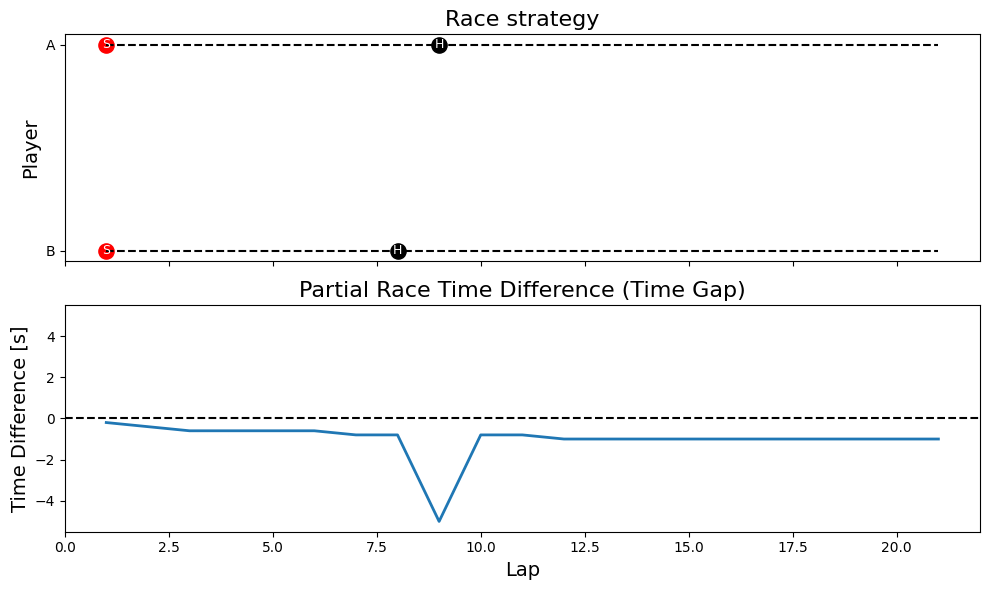

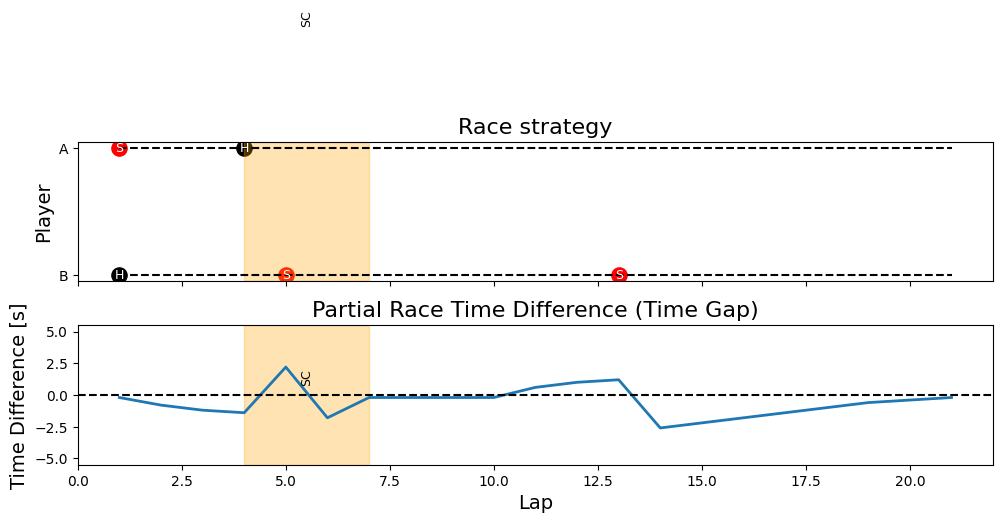

In [7]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [ ]:
# 16:14

Winner: A
Gap: -1.599999999999997
Winner: A
Gap: -2.799999999999998


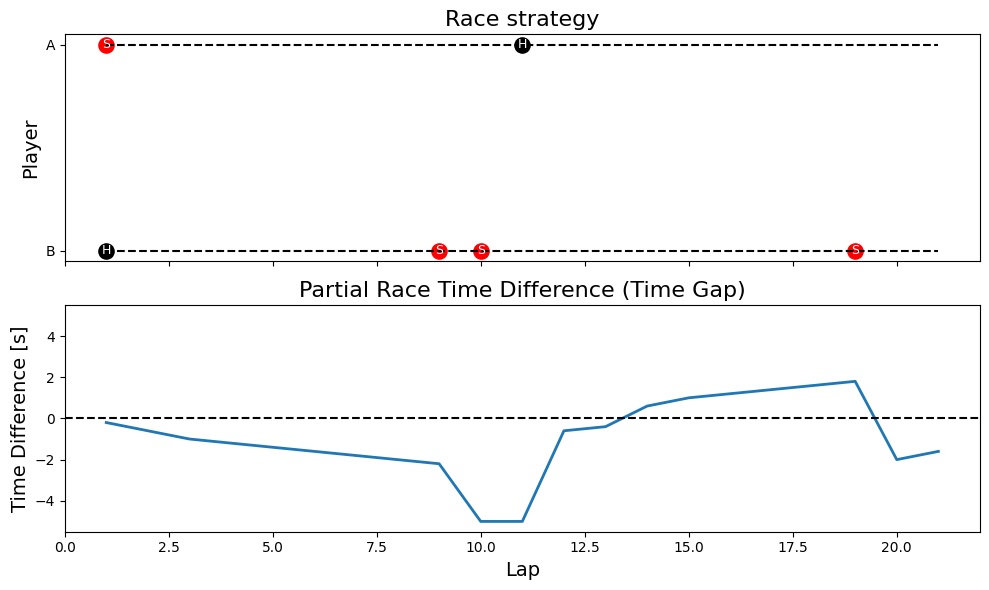

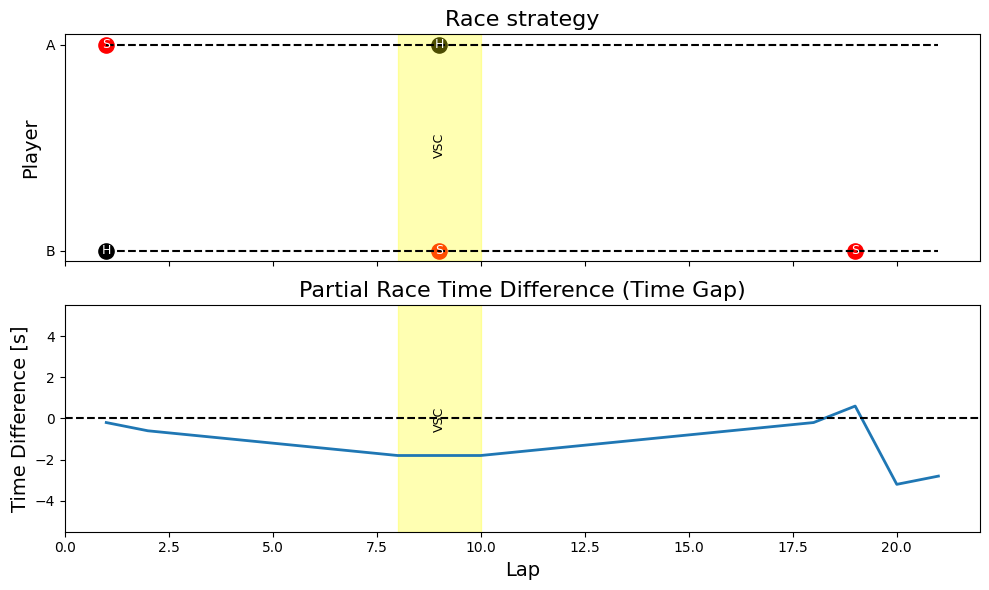

In [8]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [9]:
df_exp_SH_win

,experiment,objective,tire_set,simulation_id,final_gap,winner,A_wins,B_wins,tie,start_tire_A,start_tire_B,n_pits_A,n_pits_B,had_VSC,had_SC,mean_gap_race,std_gap_race
0,EXP_SH_win,win,"[1, 3]",0,-4.2,A,1,0,0,3,3,1,1,0,1,-0.257143,1.733857
1,EXP_SH_win,win,"[1, 3]",1,-0.2,A,1,0,0,1,3,1,1,0,0,-1.228571,0.656936
2,EXP_SH_win,win,"[1, 3]",2,0.4,B,0,1,0,1,3,2,1,0,1,-0.095238,0.922975
3,EXP_SH_win,win,"[1, 3]",3,-1.8,A,1,0,0,1,3,1,3,0,0,-1.085714,1.662553
4,EXP_SH_win,win,"[1, 3]",4,-0.8,A,1,0,0,1,1,3,3,0,0,-1.304762,1.423101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EXP_SH_win,win,"[1, 3]",9995,1.4,B,0,1,0,1,3,1,1,0,1,-0.685714,1.173633
9996,EXP_SH_win,win,"[1, 3]",9996,-1.6,A,1,0,0,1,3,1,3,0,0,-0.895238,1.824301
9997,EXP_SH_win,win,"[1, 3]",9997,-1.2,A,1,0,0,1,1,2,1,1,1,-0.590476,1.202341
9998,EXP_SH_win,win,"[1, 3]",9998,1.2,B,0,1,0,1,3,1,1,1,0,-0.847619,0.787775


Winner: A
Gap: -1.9999999999999973
Winner: A
Gap: -0.7999999999999963


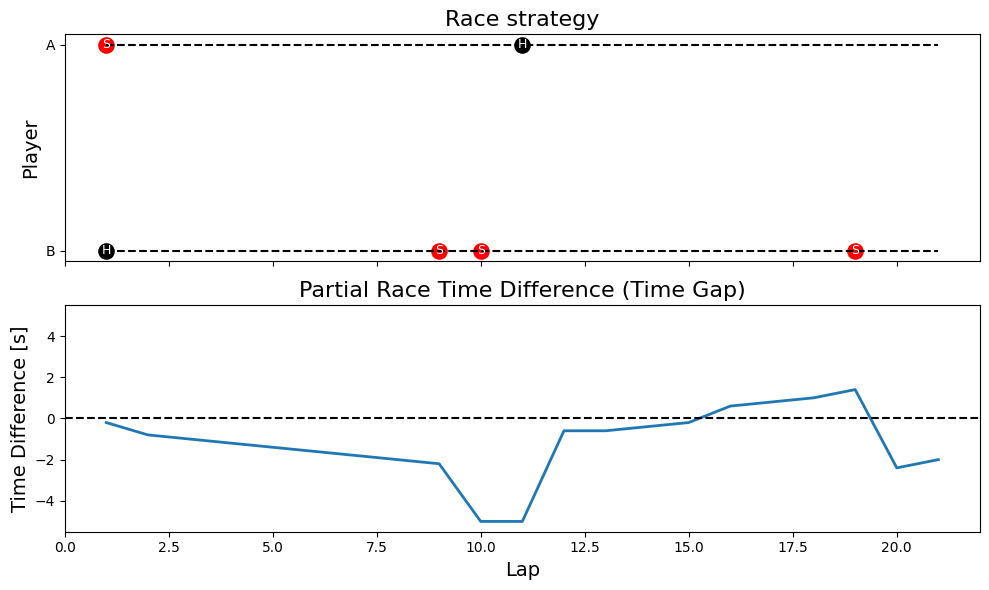

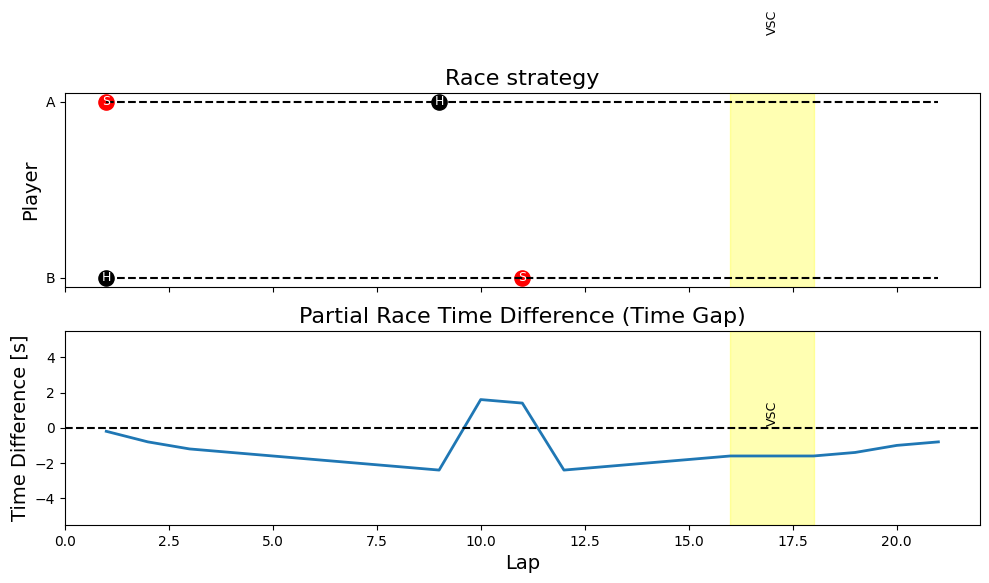

In [10]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.9999999999999964
Winner: A
Gap: -2.3999999999999977


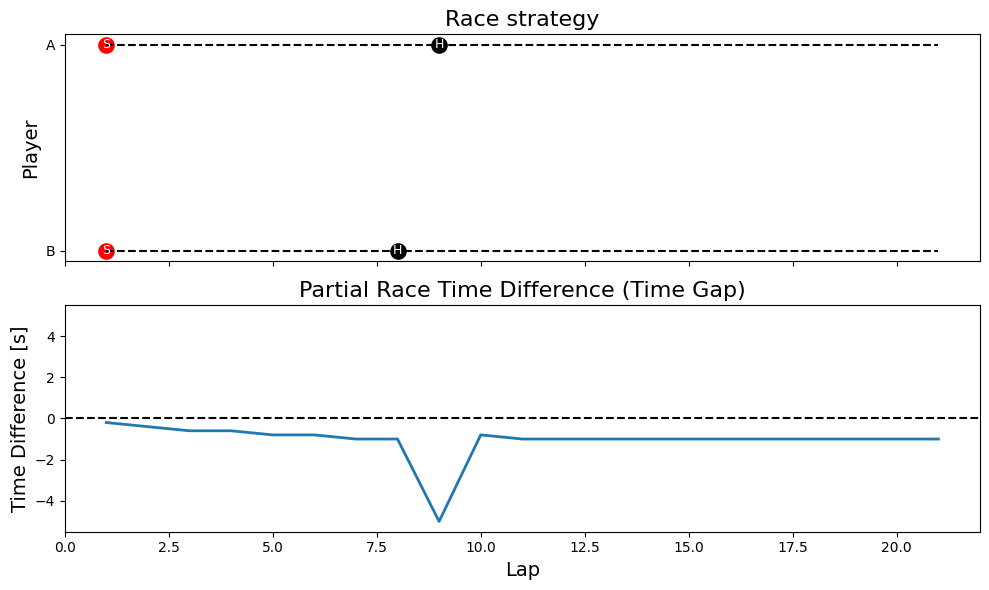

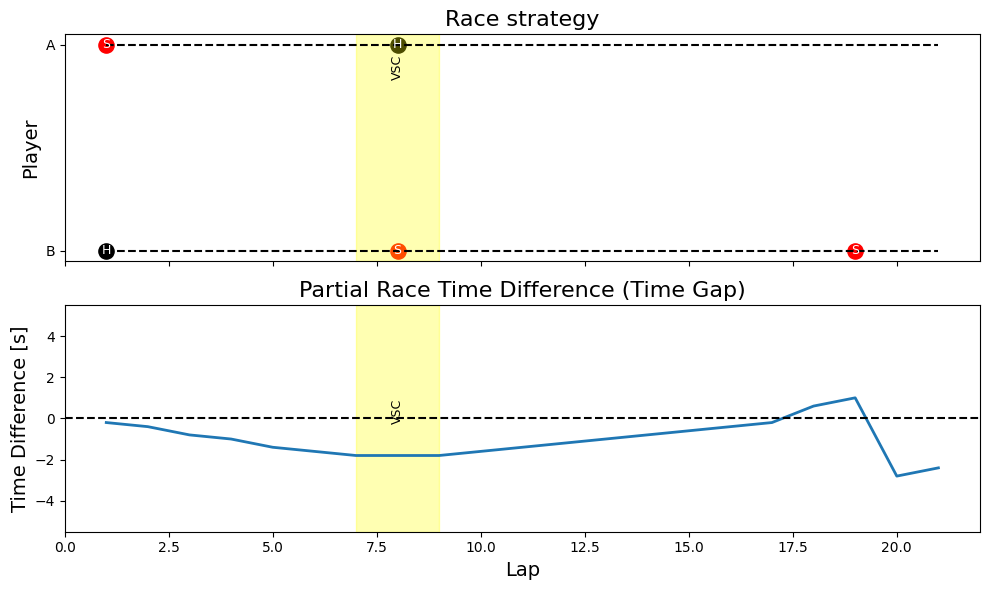

In [12]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -1.599999999999997
Winner: B
Gap: 4.440892098500626e-15


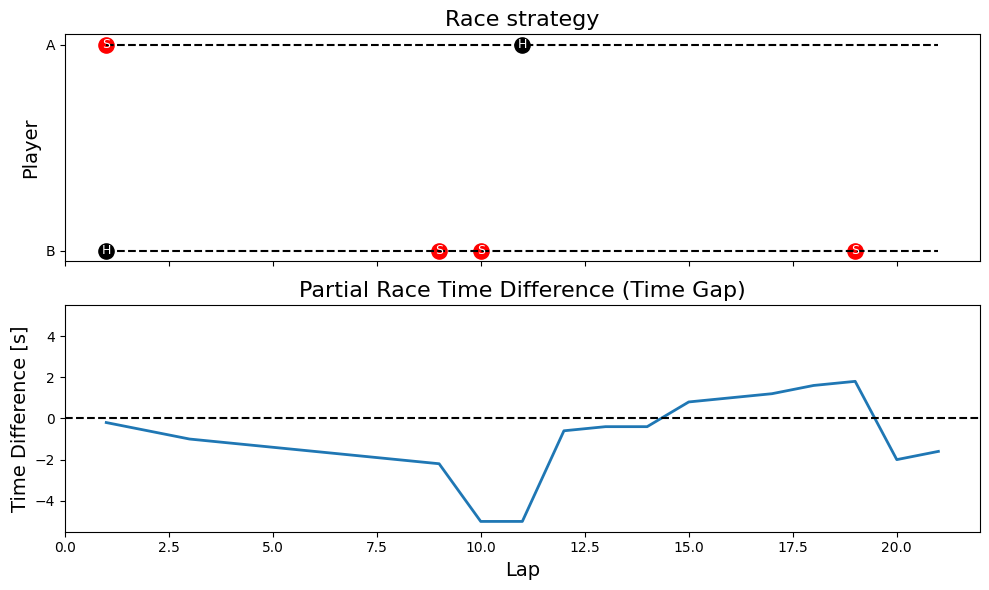

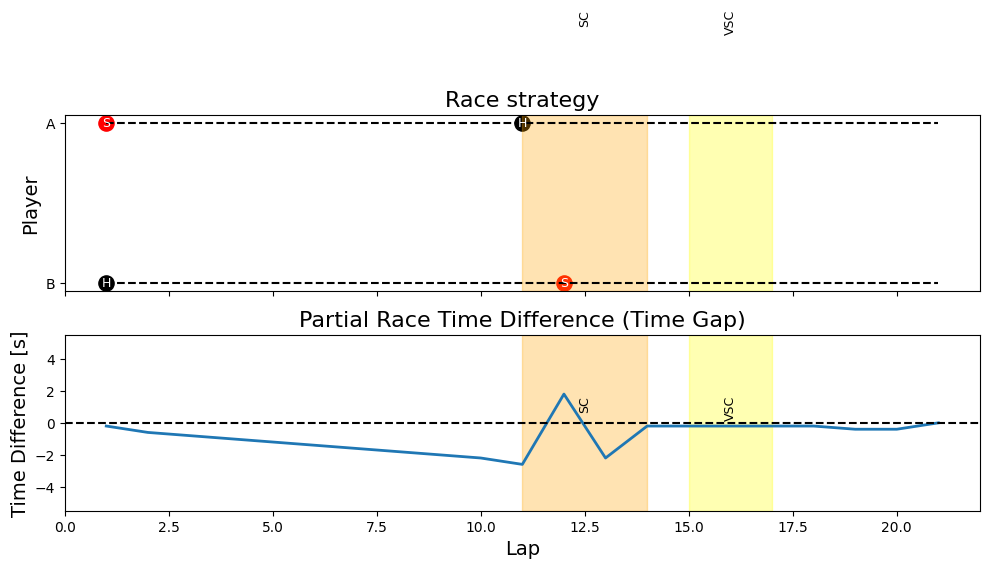

In [13]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.9999999999999964
Winner: A
Gap: -1.9999999999999973


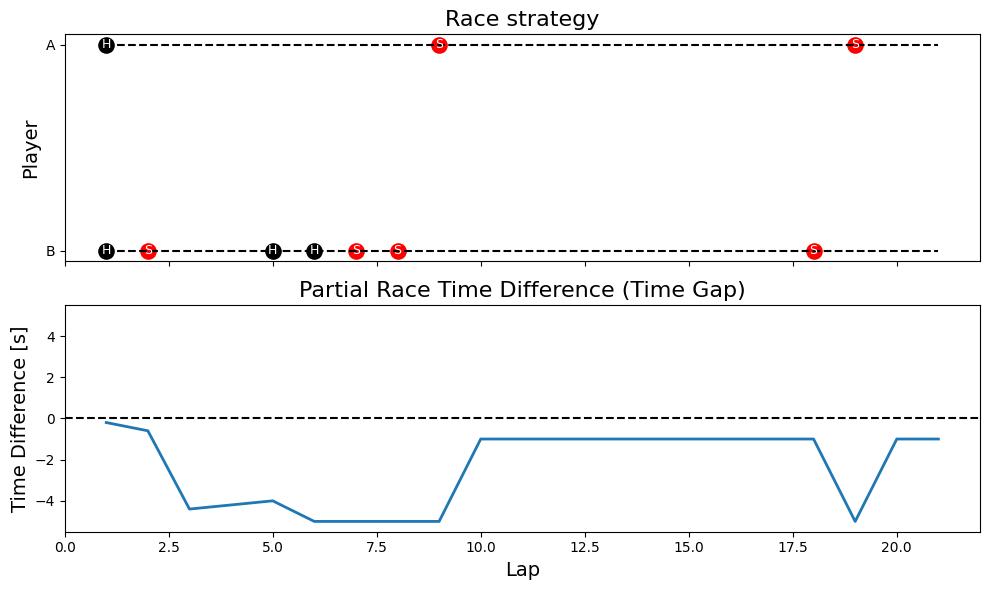

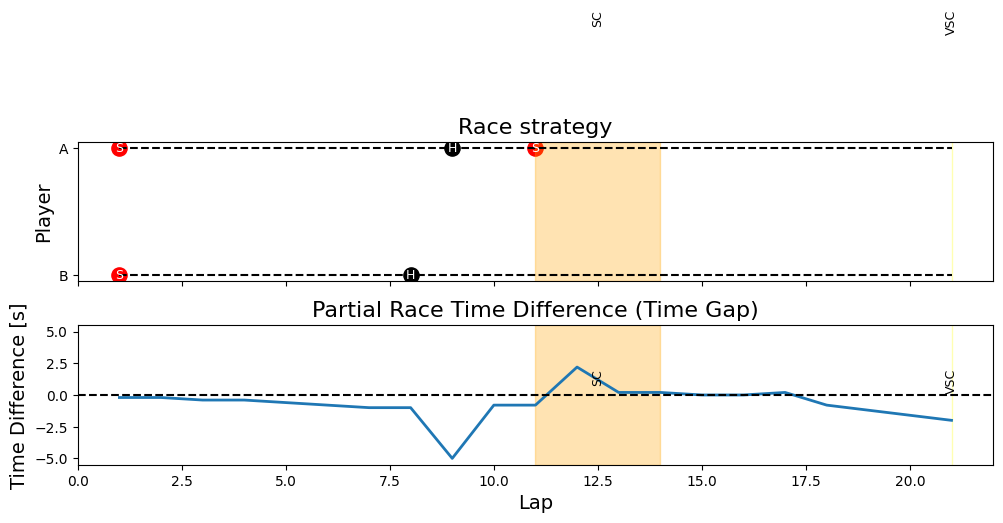

In [14]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.19999999999999574
Winner: A
Gap: -0.5999999999999961


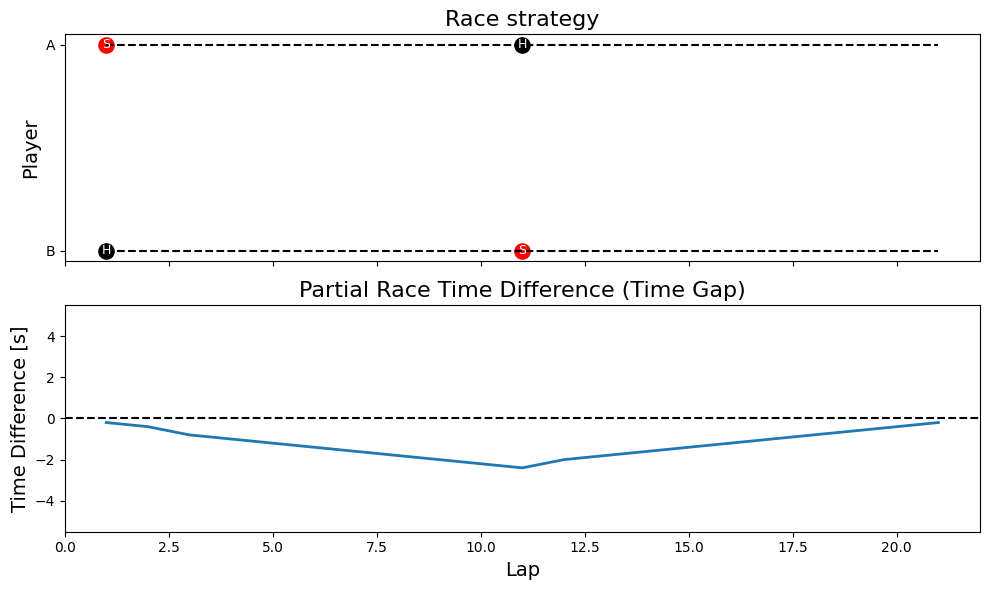

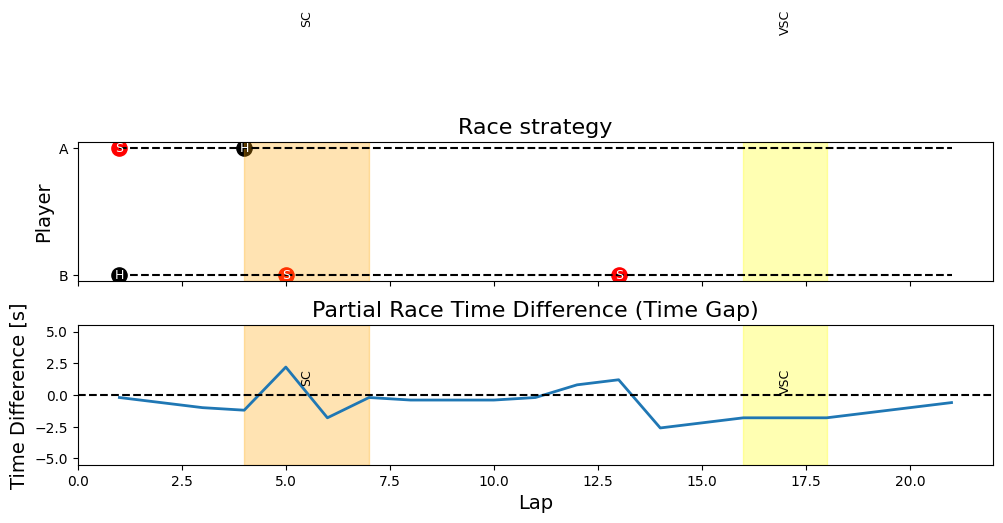

In [19]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -1.9999999999999973
Winner: B
Gap: 0.600000000000005


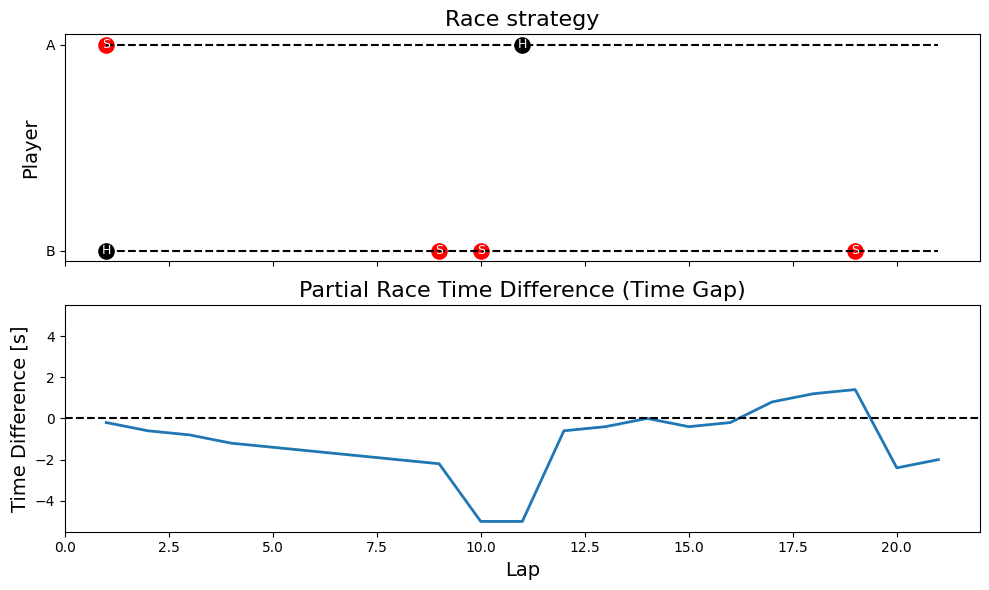

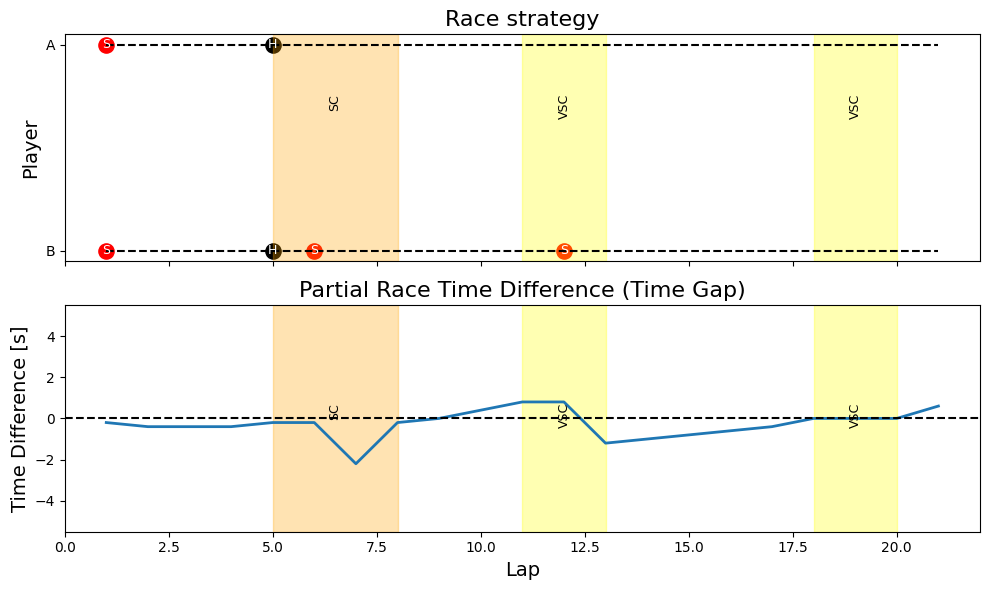

In [23]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [2]:
import pandas as pd
import numpy as np
df_SH_gap = pd.read_csv("EXP_SH_gap.csv")
df_SH_gap

,experiment,objective,tire_set,simulation_id,final_gap,winner,A_wins,B_wins,tie,start_tire_A,start_tire_B,n_pits_A,n_pits_B,had_VSC,had_SC,mean_gap_race,std_gap_race
0,EXP_SH_gap,gap,"[1, 3]",0,-1.400000e+00,A,1,0,0,3,1,1,2,1,0,-0.857143,0.656521
1,EXP_SH_gap,gap,"[1, 3]",1,-1.000000e+00,A,1,0,0,3,3,1,1,0,0,-0.847619,0.238286
2,EXP_SH_gap,gap,"[1, 3]",2,4.440892e-15,B,0,1,0,1,3,1,1,1,0,-0.828571,0.858095
3,EXP_SH_gap,gap,"[1, 3]",3,6.000000e-01,B,0,1,0,3,1,1,1,1,0,1.171429,0.693605
4,EXP_SH_gap,gap,"[1, 3]",4,-8.000000e-01,A,1,0,0,1,3,1,1,1,0,-1.571429,0.608779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EXP_SH_gap,gap,"[1, 3]",9995,-1.000000e+00,A,1,0,0,1,1,1,1,1,0,-1.038095,0.912598
9996,EXP_SH_gap,gap,"[1, 3]",9996,6.000000e-01,B,0,1,0,3,1,1,1,0,0,1.466667,0.751718
9997,EXP_SH_gap,gap,"[1, 3]",9997,-1.400000e+00,A,1,0,0,1,3,1,2,0,1,-0.504762,1.230747
9998,EXP_SH_gap,gap,"[1, 3]",9998,-2.000000e-01,A,1,0,0,1,3,1,1,0,0,-1.247619,0.638166


In [6]:
df = df_SH_gap

gaps = df["final_gap"].to_numpy()
winners = df["winner"]

summary = {
    "P(A wins)": np.mean(winners == "A"),
    "P(B wins)": np.mean(winners == "B"),
    "P(tie)": np.mean(winners == "tie"),

    "Mean gap": np.mean(gaps),
    "Std gap": np.std(gaps),

    "Mean gap | A wins": np.mean(df.loc[df["winner"] == "A", "final_gap"]),
    "Mean gap | B wins": np.mean(df.loc[df["winner"] == "B", "final_gap"]),

    "Std gap | A wins": np.std(df.loc[df["winner"] == "A", "final_gap"]),
    "Std gap | B wins": np.std(df.loc[df["winner"] == "B", "final_gap"]),
}
summary

{'P(A wins)': np.float64(0.7229),
 'P(B wins)': np.float64(0.2771),
 'P(tie)': np.float64(0.0),
 'Mean gap': np.float64(-0.40023999999999593),
 'Std gap': np.float64(0.6764672515355055),
 'Mean gap | A wins': np.float64(-0.7572278323419522),
 'Mean gap | B wins': np.float64(0.531071815229164),
 'Std gap | A wins': np.float64(0.3492922800998532),
 'Std gap | B wins': np.float64(0.36513258306401775)}

In [7]:
df_SH_win = pd.read_csv("EXP_SH_win.csv")
df_SH_win

,experiment,objective,tire_set,simulation_id,final_gap,winner,A_wins,B_wins,tie,start_tire_A,start_tire_B,n_pits_A,n_pits_B,had_VSC,had_SC,mean_gap_race,std_gap_race
0,EXP_SH_win,win,"[1, 3]",0,-4.2,A,1,0,0,3,3,1,1,0,1,-0.257143,1.733857
1,EXP_SH_win,win,"[1, 3]",1,-0.2,A,1,0,0,1,3,1,1,0,0,-1.228571,0.656936
2,EXP_SH_win,win,"[1, 3]",2,0.4,B,0,1,0,1,3,2,1,0,1,-0.095238,0.922975
3,EXP_SH_win,win,"[1, 3]",3,-1.8,A,1,0,0,1,3,1,3,0,0,-1.085714,1.662553
4,EXP_SH_win,win,"[1, 3]",4,-0.8,A,1,0,0,1,1,3,3,0,0,-1.304762,1.423101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EXP_SH_win,win,"[1, 3]",9995,1.4,B,0,1,0,1,3,1,1,0,1,-0.685714,1.173633
9996,EXP_SH_win,win,"[1, 3]",9996,-1.6,A,1,0,0,1,3,1,3,0,0,-0.895238,1.824301
9997,EXP_SH_win,win,"[1, 3]",9997,-1.2,A,1,0,0,1,1,2,1,1,1,-0.590476,1.202341
9998,EXP_SH_win,win,"[1, 3]",9998,1.2,B,0,1,0,1,3,1,1,1,0,-0.847619,0.787775


In [8]:
df = df_SH_win

gaps = df["final_gap"].to_numpy()
winners = df["winner"]

summary = {
    "P(A wins)": np.mean(winners == "A"),
    "P(B wins)": np.mean(winners == "B"),
    "P(tie)": np.mean(winners == "tie"),

    "Mean gap": np.mean(gaps),
    "Std gap": np.std(gaps),

    "Mean gap | A wins": np.mean(df.loc[df["winner"] == "A", "final_gap"]),
    "Mean gap | B wins": np.mean(df.loc[df["winner"] == "B", "final_gap"]),

    "Std gap | A wins": np.std(df.loc[df["winner"] == "A", "final_gap"]),
    "Std gap | B wins": np.std(df.loc[df["winner"] == "B", "final_gap"]),
}
summary

{'P(A wins)': np.float64(0.7041),
 'P(B wins)': np.float64(0.2959),
 'P(tie)': np.float64(0.0),
 'Mean gap': np.float64(-0.7432199999999962),
 'Std gap': np.float64(1.5226700337236574),
 'Mean gap | A wins': np.float64(-1.4548217582729694),
 'Mean gap | B wins': np.float64(0.9500506928016274),
 'Std gap | A wins': np.float64(1.1202972246286578),
 'Std gap | B wins': np.float64(0.8814443070168707)}

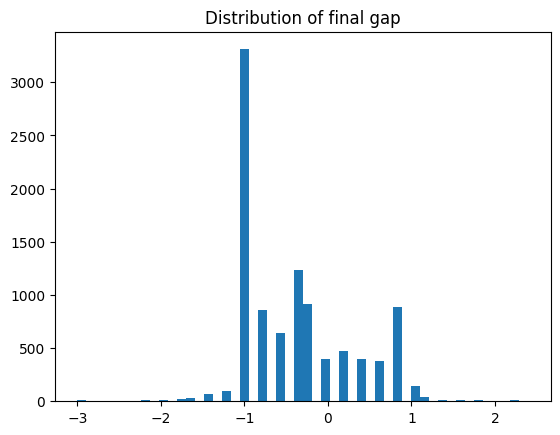

In [10]:
import matplotlib.pyplot as plt

plt.hist(df_SH_gap["final_gap"], bins=50)
plt.title("Distribution of final gap")
plt.show()

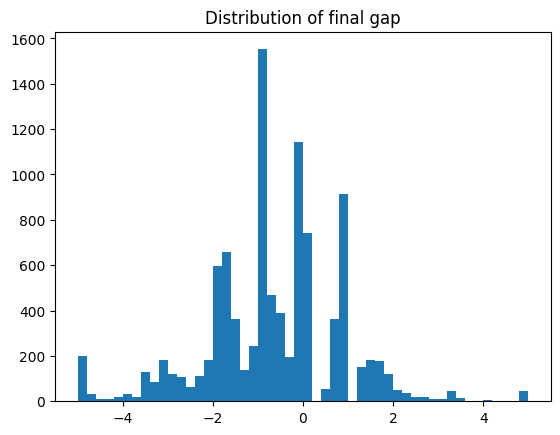

In [11]:
plt.hist(df_SH_win["final_gap"], bins=50)
plt.title("Distribution of final gap")
plt.show()

In [12]:
# variance check
from scipy.stats import levene

stat, p = levene(df_SH_gap["final_gap"], df_SH_win["final_gap"])

In [13]:
stat, p

(np.float64(2976.338946706117), np.float64(0.0))

In [14]:
np.var(df_SH_gap["final_gap"]), np.var(df_SH_win["final_gap"])

(np.float64(0.45760794240000086), np.float64(2.318524031600004))

In [15]:
from scipy.stats import ttest_ind

def compare_gap(df_gap, df_win):

    tstat, pval = ttest_ind(
        df_gap["final_gap"],
        df_win["final_gap"],
        equal_var=False
    )

    print("Gap comparison")
    print("t =", tstat)
    print("p =", pval)

In [17]:
compare_gap(df_SH_gap, df_SH_win)

Gap comparison
t = 20.58386979969444
p = 9.417232425066659e-93
